# Setup

In [1]:
from typing import Optional, Tuple

import torch
from torch import Tensor
from torch.distributions import constraints
from torch.distributions.distribution import Distribution
from torch.distributions.utils import lazy_property, logits_to_probs, probs_to_logits
from torch.distributions import Normal
from torch.fft import fft, ifft
import math
import torch.nn.functional as F

__all__ = ["PoissonBinomialExact"]

def _clamp_by_zero(x):
    return (x.clamp(min=0) + x - x.clamp(max=0)) / 2

class PoissonBinomialExact(Distribution):
    arg_constraints = {
        "probs": constraints.unit_interval,
        "logits": constraints.real,
    }
    has_enumerate_support = True
    support = constraints.nonnegative_integer

    def __init__(
        self,
        probs: Optional[Tensor] = None,
        logits: Optional[Tensor] = None,
        validate_args: Optional[bool] = True,
    ):
        if (probs is None) == (logits is None):
            raise ValueError("Either `probs` or `logits` must be specified, but not both.")
        if probs is not None:
            if not isinstance(probs, Tensor):
                probs = torch.as_tensor(probs, dtype=torch.float32)
            self.probs = probs
            self.logits = None
        else:
            if not isinstance(logits, Tensor):
                logits = torch.as_tensor(logits, dtype=torch.float32)
            self.logits = logits
            self.probs = logits_to_probs(logits)
        super().__init__(batch_shape=self.probs.shape[:-1], validate_args=False)

    def expand(self, batch_shape, _instance=None):
        new_instance = self._get_checked_instance(PoissonBinomialExact, _instance)
        new_instance.probs = self.probs.expand(batch_shape + self.probs.shape)
        super(PoissonBinomialExact, new_instance).__init__(
            batch_shape=batch_shape,
            validate_args=False,
        )
        new_instance._validate_args = self._validate_args
        return new_instance

    def pmf(self):
        probs = self.probs.to(dtype=torch.float64)
        batch_shape = probs.shape[:-1]
        n = probs.shape[-1]
        N = n + 1
        j = torch.arange(N, device=device, dtype=torch.float64)
        omega = torch.exp(2j * math.pi * j / N)
        p_i = probs.unsqueeze(-1)
        term = (1 - p_i) + p_i * omega
        cf = torch.ones(batch_shape + (N,), dtype=torch.complex128, device=device)

        for i in range(n):
            cf = cf * ((1 - probs[..., i, None]) + probs[..., i, None] * omega)

        pmf = torch.fft.fft(cf, dim=-1).real / N
        pmf = pmf.clamp_(min=0.0)

        return pmf.to(self.probs.dtype)

    def cdf(self, value=None):
        pmf = self.pmf()
        cdf_full = torch.cumsum(pmf, dim=-1)

        if value is None:
            return cdf_full

        value = torch.as_tensor(value, dtype=torch.long, device=pmf.device)
        value = value.clamp_(min=0, max=pmf.shape[-1]-1)

        if len(self.batch_shape) == 0:
            return cdf_full[value]
        else:
            if value.shape[:len(self.batch_shape)] != self.batch_shape:
                raise ValueError(
                    f"Expected value to have batch prefix {self.batch_shape}, "
                    f"got shape {value.shape}"
                )
            indices = value.unsqueeze(-1)
            return cdf_full.gather(-1, indices).squeeze(-1)

    def icdf(self, value=None, method="searchsorted"):
        pmf = self.pmf()
        cdf_full = torch.cumsum(pmf, dim=-1)

        if value is None:
            return cdf_full

        value = torch.as_tensor(value, dtype=torch.float32, device=pmf.device)
        value = value.clamp_(min=0.0, max=1.0)
        if method.lower() == 'searchsorted':
            icdf_values = torch.searchsorted(cdf_full, value, right=True)
            return icdf_values
        elif method.lower() == 'bisection':
            support_size = cdf_full.shape[-1]
            value = value.to(dtype=torch.float32, device=pmf.device)
            low = torch.zeros_like(value, dtype=torch.long)
            high = torch.full_like(value, support_size - 1, dtype=torch.long)
            # Expand cdf_full if no batch dimension
            if cdf_full.dim() == 1:
                # Single distribution case
                for _ in range(int(math.ceil(math.log2(support_size)))):
                    mid = (low + high) // 2
                    cdf_mid = cdf_full[mid]  # direct indexing
                    low = torch.where(cdf_mid < value, mid + 1, low)
                    high = torch.where(cdf_mid < value, high, mid)
                    
                low = torch.minimum(low, torch.tensor(cdf_full.size(-1) - 1, device=low.device, dtype=low.dtype))
                cdf_low = cdf_full[low]
                result = torch.where(cdf_low >= value, low, high)

            else:
                # Batched case: cdf_full shape [batch..., support_size]
                for _ in range(int(math.ceil(math.log2(support_size)))):
                    mid = (low + high) // 2
                    cdf_mid = torch.gather(cdf_full, -1, mid.unsqueeze(-1)).squeeze(-1)
                    low = torch.where(cdf_mid < value, mid + 1, low)
                    high = torch.where(cdf_mid < value, high, mid)

                cdf_low = torch.gather(cdf_full, -1, low.unsqueeze(-1)).squeeze(-1)
                result = torch.where(cdf_low >= value, low, high)

            return result.clamp(max=support_size - 1)
        else:
            raise ValueError("method must be 'searchsorted' or 'bisection'")

    @property
    def mean(self) -> Tensor:
        return self.probs.sum(-1)

    @property
    def variance(self) -> Tensor:
        return (self.probs * (1 - self.probs)).sum(-1)

    @property
    def skewness(self) -> Tensor:
        p = self.probs
        term = p * (1 - p) * (1 - 2 * p)
        return term.sum(-1) / self.variance.clamp(min=1e-8).pow(1.5)

    @property
    def mode(self) -> Tensor:
        return self.pmf().argmax(dim=-1)

    @property
    def param_shape(self) -> torch.Size:
        return self._param.size()

c:\Users\matth\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


In [ ]:
from typing import Optional, Tuple

import torch
from torch import Tensor
from torch.distributions import constraints
from torch.distributions.distribution import Distribution
from torch.distributions.utils import lazy_property, logits_to_probs, probs_to_logits
from torch.distributions import Normal
from torch.fft import fft, ifft
import math
import torch.nn.functional as F

__all__ = ["PoissonBinomialApprox"]

def _clamp_by_zero(x):
    return (x.clamp(min=0) + x - x.clamp(max=0)) / 2

class PoissonBinomialApprox(Distribution):
    arg_constraints = {
        "probs": constraints.unit_interval,
        "logits": constraints.real,
    }
    has_enumerate_support = True
    support = constraints.nonnegative_integer

    def __init__(
        self,
        probs: Optional[Tensor] = None,
        logits: Optional[Tensor] = None,
        validate_args: Optional[bool] = True,
    ):
        if (probs is None) == (logits is None):
            raise ValueError("Either `probs` or `logits` must be specified, but not both.")
        if probs is not None:
            if not isinstance(probs, Tensor):
                probs = torch.as_tensor(probs, dtype=torch.float32)
            self.probs = probs
            self.logits = None
        else:
            if not isinstance(logits, Tensor):
                logits = torch.as_tensor(logits, dtype=torch.float32)
            self.logits = logits
            self.probs = logits_to_probs(logits)
        super().__init__(batch_shape=self.probs.shape[:-1], validate_args=False)

    def expand(self, batch_shape, _instance=None):
        new_instance = self._get_checked_instance(PoissonBinomialApprox, _instance)
        new_instance.probs = self.probs.expand(batch_shape + self.probs.shape)
        super(PoissonBinomialApprox, new_instance).__init__(
            batch_shape=batch_shape,
            validate_args=False,
        )
        new_instance._validate_args = self._validate_args
        return new_instance

    def pmf(self):
        probs = self.probs.to(dtype=torch.float64)
        batch_shape = probs.shape[:-1]
        n = probs.shape[-1]

        if n == 0:
            return torch.ones(batch_shape + (1,), device=device, dtype=self.probs.dtype)

        mu = probs.sum(dim=-1, keepdim=True)
        var = (probs * (1 - probs)).sum(dim=-1, keepdim=True)
        sigma = var.sqrt().clamp_(min=1e-10)

        degenerate = (var <= 1e-8).squeeze(-1)         
        if degenerate.all():
            pmf = torch.zeros(batch_shape + (n + 1,), device=device, dtype=torch.float64)
            mu_clamped = mu.squeeze(-1).clamp(0, n)
            k_peak = torch.round(mu_clamped).long()  
            pmf.scatter_(dim=-1,
                 index=k_peak.unsqueeze(-1), 
                 value=1.0)
            return pmf.to(self.probs.dtype)

        mu3 = (probs * (1 - probs) * (1 - 2 * probs)).sum(dim=-1, keepdim=True)
        skew = mu3 / (sigma ** 3)
        k = torch.arange(n + 1, device=device, dtype=torch.float64)
        k = k.view((1,) * len(batch_shape) + (n+1,))
        z = (k - mu) / sigma

        phi = torch.exp(-0.5 * z * z) / math.sqrt(2 * math.pi)
        correction = (skew / 6.0) * (z * z - 1.0) * phi
        pdf_approx = phi + correction
        pmf = pdf_approx.clamp_(min=0.0)

        total = pmf.sum(dim=-1, keepdim=True).clamp(min=1e-12)
        pmf = pmf / total

        return pmf.to(self.probs.dtype)


    def cdf(self, value=None):
        pmf = self.pmf()
        cdf_full = torch.cumsum(pmf, dim=-1)

        if value is None:
            return cdf_full

        value = torch.as_tensor(value, dtype=torch.long, device=pmf.device)
        value = value.clamp_(min=0, max=pmf.shape[-1]-1)

        if len(self.batch_shape) == 0:
            return cdf_full[value]
        else:
            if value.shape[:len(self.batch_shape)] != self.batch_shape:
                raise ValueError(
                    f"Expected value to have batch prefix {self.batch_shape}, "
                    f"got shape {value.shape}"
                )
            indices = value.unsqueeze(-1)
            return cdf_full.gather(-1, indices).squeeze(-1)

    def icdf(self, value=None, method="searchsorted"):
        pmf = self.pmf()
        cdf_full = torch.cumsum(pmf, dim=-1)

        if value is None:
            return cdf_full

        value = torch.as_tensor(value, dtype=torch.float32, device=pmf.device)
        value = value.clamp_(min=0.0, max=1.0)
        if method.lower() == 'searchsorted':
            icdf_values = torch.searchsorted(cdf_full, value, right=True)
            return icdf_values
        elif method.lower() == 'bisection':
            support_size = cdf_full.shape[-1]
            value = value.to(dtype=torch.float32, device=pmf.device)
            low = torch.zeros_like(value, dtype=torch.long)
            high = torch.full_like(value, support_size - 1, dtype=torch.long)
            # Expand cdf_full if no batch dimension
            if cdf_full.dim() == 1:
                # Single distribution case
                for _ in range(int(math.ceil(math.log2(support_size)))):
                    mid = (low + high) // 2
                    cdf_mid = cdf_full[mid]  # direct indexing
                    low = torch.where(cdf_mid < value, mid + 1, low)
                    high = torch.where(cdf_mid < value, high, mid)
                    
                low = torch.minimum(low, torch.tensor(cdf_full.size(-1) - 1, device=low.device, dtype=low.dtype))
                cdf_low = cdf_full[low]
                result = torch.where(cdf_low >= value, low, high)

            else:
                # Batched case: cdf_full shape [batch..., support_size]
                for _ in range(int(math.ceil(math.log2(support_size)))):
                    mid = (low + high) // 2
                    cdf_mid = torch.gather(cdf_full, -1, mid.unsqueeze(-1)).squeeze(-1)
                    low = torch.where(cdf_mid < value, mid + 1, low)
                    high = torch.where(cdf_mid < value, high, mid)

                cdf_low = torch.gather(cdf_full, -1, low.unsqueeze(-1)).squeeze(-1)
                result = torch.where(cdf_low >= value, low, high)

            return result.clamp(max=support_size - 1)
        else:
            raise ValueError("method must be 'searchsorted' or 'bisection'")

    @property
    def mean(self) -> Tensor:
        return self.probs.sum(-1)

    @property
    def variance(self) -> Tensor:
        return (self.probs * (1 - self.probs)).sum(-1)

    @property
    def skewness(self) -> Tensor:
        p = self.probs
        term = p * (1 - p) * (1 - 2 * p)
        return term.sum(-1) / self.variance.clamp(min=1e-8).pow(1.5)

    @property
    def mode(self) -> Tensor:
        return self.pmf().argmax(dim=-1)

    @property
    def param_shape(self) -> torch.Size:
        return self._param.size()

# Testing (TAE and Running Time for PMF and ICDF)



In [2]:
import torch
import time

# ─── Sample Generation (Torch-native, GPU-ready) ───────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
rng = torch.Generator(device=device).manual_seed(6211)

def make_samples(n, p):
    # Uniform
    sample_case_1 = torch.rand((n, p), generator=rng, device=device)

    # Beta distributions
    beta = torch.distributions.Beta
    sample_case_2 = beta(0.1, 3.0).sample((n, p)).to(device)
    sample_case_3 = beta(3.0, 0.1).sample((n, p)).to(device)
    sample_case_4 = 0.5 * sample_case_2 + 0.5 * sample_case_3
    sample_case_5 = beta(3.0, 3.0).sample((n, p)).to(device)
    sample_case_6 = 0.5 * beta(3.0, 10.0).sample((n, p)).to(device) + 0.5 * beta(10.0, 3.0).sample((n, p)).to(device)

    return [sample_case_1, sample_case_2, sample_case_3,
            sample_case_4, sample_case_5, sample_case_6]

samples = make_samples(100, 15000)

In [14]:
import torch
import time

# Quantiles we evaluate
qs = torch.tensor([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])

def compute_tae_pmf_and_icdf_batched():
    headers = [
        "Pattern".ljust(22),
        "n".rjust(6),
        "TAE PMF".rjust(14),
        "TAE ICDF (Searchsorted)".rjust(15),
        "TAE ICDF (Bisection)".rjust(15),
        "Exact PMF time".rjust(14),
        "Approx PMF time".rjust(15),
        "Exact ICDF time (Searchsorted)".rjust(14),
        "Exact ICDF time (Bisection)".rjust(14),
        "Approx ICDF time (Searchsorted)".rjust(15),
        "Approx ICDF time (Bisection)".rjust(15)
    ]
    print("  ".join(headers))
    print("-" * 140)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}\n")
    #n_values = [10, 20, 50, 100, 200, 500, 1000, 2000, 5000]#, 10000, 15000]
    n_values = [10, 20, 50, 100, 200, 500, 1000, 2000, 3000, 4000, 5000]
    for case in range(len(samples)):
        for n in n_values:
            pmf_error = []
            icdf_searchsorted_error = []
            icdf_bisection_error = []
            pmf_exact_time = []
            pmf_approx_time = []
            icdf_searchsorted_exact_time = []
            icdf_bisection_exact_time = []
            icdf_searchsorted_approx_time = []
            icdf_bisection_approx_time = []
            for j in range(len(samples[case])):
                probs = samples[case][j][:n]
                
                torch.cuda.synchronize() if device.type == "cuda" else None
                
                exact = PoissonBinomialExact(probs)
                approx = PoissonBinomialApprox(probs)
                
                start_time = time.time()
                pmf_exact  = exact.pmf()
                pmf_exact_time.append(time.time() - start_time)

                start_time = time.time()
                pmf_approx = approx.pmf()
                pmf_approx_time.append(time.time() - start_time)

                pmf_error.append((pmf_exact.float() - pmf_approx.float()).abs().sum().item())
                
                start_time = time.time()
                icdf_exact  = exact.icdf(qs)
                icdf_searchsorted_exact_time.append(time.time() - start_time)

                start_time = time.time()
                icdf_approx = approx.icdf(qs)
                icdf_searchsorted_approx_time.append(time.time() - start_time)

                start_time = time.time()
                icdf_exact_bisect = exact.icdf(qs, method='searchsorted')
                icdf_searchsorted_exact_time.append(time.time() - start_time)

                start_time = time.time()
                icdf_approx_bisect = approx.icdf(qs, method='searchsorted')
                icdf_searchsorted_approx_time.append(time.time() - start_time)

                start_time = time.time()
                icdf_exact_bisect = exact.icdf(qs, method='bisection')
                icdf_bisection_exact_time.append(time.time() - start_time)

                start_time = time.time()
                icdf_approx_bisect = approx.icdf(qs, method='bisection')
                icdf_bisection_approx_time.append(time.time() - start_time)
                
                icdf_searchsorted_error.append((icdf_exact.float() - icdf_exact_bisect.float()).abs().sum().item())
                icdf_bisection_error.append((icdf_exact.float() - icdf_approx_bisect.float()).abs().sum().item())

            avg_pmf_error = sum(pmf_error) / len(pmf_error)
            avg_icdf_searchsorted_error = sum(icdf_searchsorted_error) / len(icdf_searchsorted_error)
            avg_icdf_bisection_error = sum(icdf_bisection_error) / len(icdf_bisection_error)
            avg_pmf_exact_time = sum(pmf_exact_time) / len(pmf_exact_time)
            avg_pmf_approx_time = sum(pmf_approx_time) / len(pmf_approx_time)
            avg_icdf_searchsorted_exact_time = sum(icdf_searchsorted_exact_time) / len(icdf_searchsorted_exact_time)
            avg_icdf_bisection_exact_time = sum(icdf_bisection_exact_time) / len(icdf_bisection_exact_time)
            avg_icdf_searchsorted_approx_time = sum(icdf_searchsorted_approx_time) / len(icdf_searchsorted_approx_time)
            avg_icdf_bisection_approx_time = sum(icdf_bisection_approx_time) / len(icdf_bisection_approx_time)
            row = [
                    f"Case {case+1}".ljust(22),
                    f"{n:6d}",
                    f"{avg_pmf_error:9.4f}".rjust(14),
                    f"{avg_icdf_searchsorted_error:10.4f}".rjust(15),
                    f"{avg_icdf_bisection_error:10.4f}".rjust(15),
                    f"{avg_pmf_exact_time:9.4f} s".rjust(14),
                    f"{avg_pmf_approx_time:10.4f} s".rjust(15),
                    f"{avg_icdf_searchsorted_exact_time:9.4f} s".rjust(14),
                    f"{avg_icdf_bisection_exact_time:9.4f} s".rjust(14),
                    f"{avg_icdf_searchsorted_approx_time:10.4f} s".rjust(15),
                    f"{avg_icdf_bisection_approx_time:10.4f} s".rjust(15)
                ]
            print("  ".join(row))

    print("\nNotes:")
    print("• TAE PMF (mean) = average over batch of ∑|pmf_exact - pmf_approx|")
    print("• MAE ICDF       = mean absolute error across all quantiles and all samples")
    print("• time(s)        = wall-clock time for the whole case (including object creation)")

if __name__ == "__main__":
    print("Running benchmark ...\n")
    compute_tae_pmf_and_icdf_batched()

Running benchmark ...

Pattern                      n         TAE PMF  TAE ICDF (Searchsorted)  TAE ICDF (Bisection)  Exact PMF time  Approx PMF time  Exact ICDF time (Searchsorted)  Exact ICDF time (Bisection)  Approx ICDF time (Searchsorted)  Approx ICDF time (Bisection)
--------------------------------------------------------------------------------------------------------------------------------------------
Using device: cpu

Case 1                      10          0.0276           0.0000           0.1500        0.0010 s         0.0005 s        0.0012 s        0.0017 s         0.0007 s         0.0012 s
Case 1                      20          0.0139           0.0000           0.0700        0.0020 s         0.0005 s        0.0018 s        0.0024 s         0.0006 s         0.0009 s
Case 1                      50          0.0056           0.0000           0.0900        0.0043 s         0.0004 s        0.0043 s        0.0049 s         0.0005 s         0.0011 s
Case 1                    

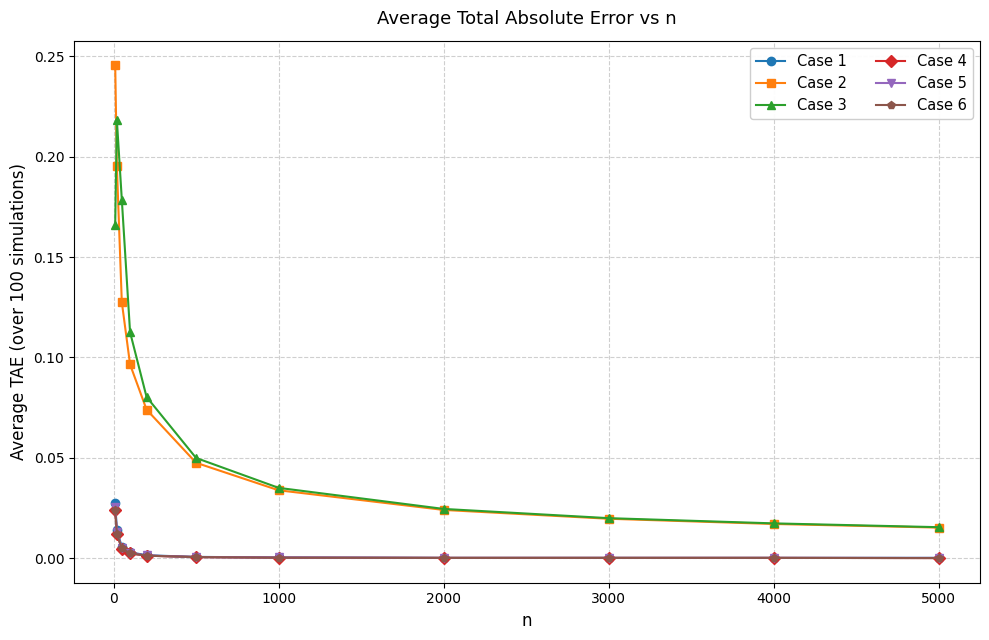

In [1]:
import matplotlib.pyplot as plt

# Data from the table
n = [10, 20, 50, 100, 200, 500, 1000, 2000, 3000, 4000, 5000]

case1 = [0.0276, 0.0139, 0.0056, 0.0029, 0.0014, 0.0006, 0.0003, 0.0001, 0.0001, 0.0001, 0.0001]
case2 = [0.2456, 0.1954, 0.1276, 0.0965, 0.0740, 0.0475, 0.0338, 0.0240, 0.0196, 0.0170, 0.0152]
case3 = [0.1662, 0.2184, 0.1787, 0.1126, 0.0803, 0.0499, 0.0350, 0.0245, 0.0199, 0.0173, 0.0154]
case4 = [0.0238, 0.0120, 0.0047, 0.0023, 0.0012, 0.0005, 0.0002, 0.0001, 0.0001, 0.0001, 0.0000]
case5 = [0.0255, 0.0130, 0.0049, 0.0025, 0.0013, 0.0005, 0.0003, 0.0001, 0.0001, 0.0001, 0.0001]
case6 = [0.0242, 0.0122, 0.0048, 0.0024, 0.0012, 0.0005, 0.0002, 0.0001, 0.0001, 0.0001, 0.0000]

# Create the plot
plt.figure(figsize=(10, 6.5))

plt.plot(n, case1, marker='o', linestyle='-', linewidth=1.5, markersize=6, label='Case 1')
plt.plot(n, case2, marker='s', linestyle='-', linewidth=1.5, markersize=6, label='Case 2')
plt.plot(n, case3, marker='^', linestyle='-', linewidth=1.5, markersize=6, label='Case 3')
plt.plot(n, case4, marker='D', linestyle='-', linewidth=1.5, markersize=6, label='Case 4')
plt.plot(n, case5, marker='v', linestyle='-', linewidth=1.5, markersize=6, label='Case 5')
plt.plot(n, case6, marker='p', linestyle='-', linewidth=1.5, markersize=6, label='Case 6')

plt.xlabel('n', fontsize=12)
plt.ylabel('Average TAE (over 100 simulations)', fontsize=12)
plt.title('Average Total Absolute Error vs n', fontsize=13, pad=12)

plt.grid(True, which="both", ls="--", alpha=0.6)
plt.legend(fontsize=10.5, loc='upper right', framealpha=0.95, ncol=2)

plt.tight_layout()
plt.show()

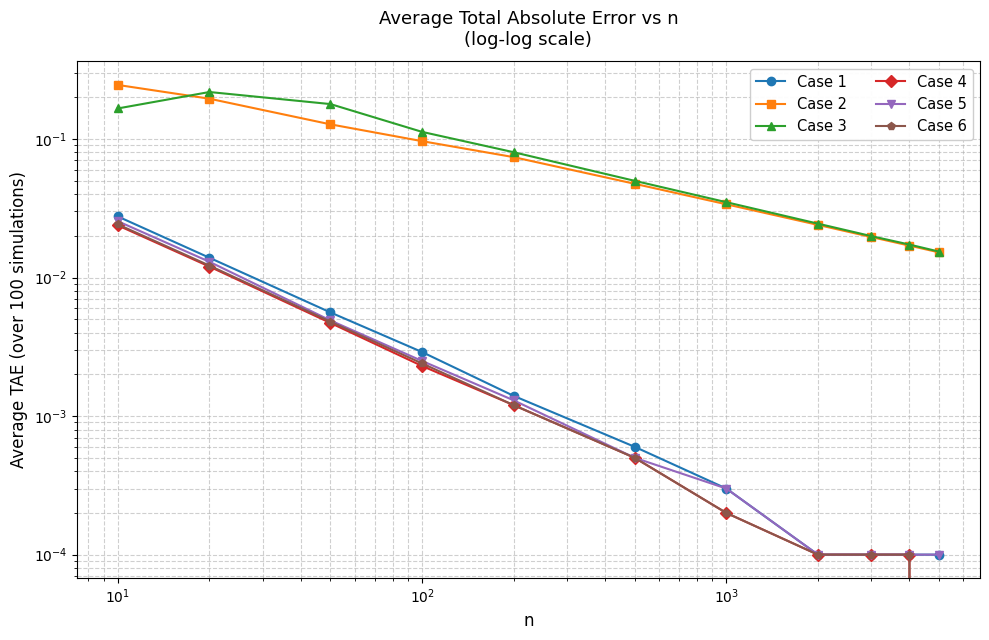

In [5]:
import matplotlib.pyplot as plt

# Data from the table
n = [10, 20, 50, 100, 200, 500, 1000, 2000, 3000, 4000, 5000]

case1 = [0.0276, 0.0139, 0.0056, 0.0029, 0.0014, 0.0006, 0.0003, 0.0001, 0.0001, 0.0001, 0.0001]
case2 = [0.2456, 0.1954, 0.1276, 0.0965, 0.0740, 0.0475, 0.0338, 0.0240, 0.0196, 0.0170, 0.0152]
case3 = [0.1662, 0.2184, 0.1787, 0.1126, 0.0803, 0.0499, 0.0350, 0.0245, 0.0199, 0.0173, 0.0154]
case4 = [0.0238, 0.0120, 0.0047, 0.0023, 0.0012, 0.0005, 0.0002, 0.0001, 0.0001, 0.0001, 0.0000]
case5 = [0.0255, 0.0130, 0.0049, 0.0025, 0.0013, 0.0005, 0.0003, 0.0001, 0.0001, 0.0001, 0.0001]
case6 = [0.0242, 0.0122, 0.0048, 0.0024, 0.0012, 0.0005, 0.0002, 0.0001, 0.0001, 0.0001, 0.0000]

# Create the plot
plt.figure(figsize=(10, 6.5))

plt.loglog(n, case1, marker='o', linestyle='-', linewidth=1.5, markersize=6, label='Case 1')
plt.loglog(n, case2, marker='s', linestyle='-', linewidth=1.5, markersize=6, label='Case 2')
plt.loglog(n, case3, marker='^', linestyle='-', linewidth=1.5, markersize=6, label='Case 3')
plt.loglog(n, case4, marker='D', linestyle='-', linewidth=1.5, markersize=6, label='Case 4')
plt.loglog(n, case5, marker='v', linestyle='-', linewidth=1.5, markersize=6, label='Case 5')
plt.loglog(n, case6, marker='p', linestyle='-', linewidth=1.5, markersize=6, label='Case 6')

plt.xlabel('n', fontsize=12)
plt.ylabel('Average TAE (over 100 simulations)', fontsize=12)
plt.title('Average Total Absolute Error vs n\n(log-log scale)', fontsize=13, pad=12)

plt.grid(True, which="both", ls="--", alpha=0.6)
plt.legend(fontsize=10.5, loc='upper right', framealpha=0.95, ncol=2)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from scipy.stats import norm

def poisson_binomial_quantile(alpha, p, max_iter=50, tol=1e-8, fallback_to_normal=True):
    p = np.asarray(p, dtype=float)
    if not (0 < alpha < 1):
        raise ValueError("alpha must be in (0,1)")
    if len(p) == 0:
        raise ValueError("p vector cannot be empty")
    if np.any((p < 0) | (p > 1)):
        raise ValueError("All probabilities must be in [0,1]")

    # Step A: moments
    mu = np.sum(p)
    var = np.sum(p * (1 - p))
    if var <= 1e-12:
        # degenerate case — all p=0 or all p=1
        return int(round(mu))

    sigma = np.sqrt(var)

    skew_sum = np.sum(p * (1 - p) * (1 - 2 * p))
    gamma = skew_sum / (sigma**3)          # skewness

    # Edgeworth correction coefficient
    gamma6 = gamma / 6.0

    def z(x):
        return (x + 0.5 - mu) / sigma

    def F_RNA(x):
        zv = z(x)
        phi = norm.pdf(zv)
        Phi = norm.cdf(zv)
        correction = gamma6 * (zv**2 - 1) * phi
        return Phi - correction

    def f_RNA(x):  # approximate pdf = dF/dx
        zv = z(x)
        phi = norm.pdf(zv)
        term = 1 - gamma6 * (3 * zv - zv**3)
        return (1 / sigma) * phi * term

    # -------------------------------------------------
    # Initial guess — plain normal approximation
    # -------------------------------------------------
    x = mu + sigma * norm.ppf(alpha)
    # better starting point with continuity correction
    x = mu - 0.5 + sigma * norm.ppf(alpha)

    # Newton-Raphson
    for i in range(max_iter):
        fx = F_RNA(x) - alpha
        fpx = f_RNA(x)

        if abs(fx) < tol:
            break

        if fpx <= 1e-10:
            if fallback_to_normal:
                # fall back — derivative became negative / too small
                x = mu - 0.5 + sigma * norm.ppf(alpha)
                break
            else:
                raise RuntimeError("Derivative became non-positive — likely far tail or extreme skewness")

        delta = fx / fpx
        x -= delta

    k = int(np.ceil(x - 1e-10))

    return k

In [4]:
qs = torch.tensor([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])
n_values = [10, 20, 50, 100, 200, 500, 1000, 2000, 3000, 4000, 5000]
for case in range(len(samples)):
    for n in n_values:
        icdf_newton_error = []
        for j in range(len(samples[case])):
            probs = samples[case][j][:n]
                
            torch.cuda.synchronize() if device.type == "cuda" else None
            
            exact = PoissonBinomialExact(probs)
            icdf_exact  = exact.icdf(qs)
            icdf_newton = torch.tensor([poisson_binomial_quantile(q.item(), probs.cpu().numpy()) for q in qs], device=probs.device)
            icdf_newton_error.append((icdf_exact.float() - icdf_newton.float()).abs().sum().item())
        avg_icdf_newton_error = sum(icdf_newton_error) / len(icdf_newton_error)
        print(f"Case {case+1}, n={n}: Avg ICDF Newton Error = {avg_icdf_newton_error:.4f}")

Case 1, n=10: Avg ICDF Newton Error = 0.0500
Case 1, n=20: Avg ICDF Newton Error = 0.0800
Case 1, n=50: Avg ICDF Newton Error = 0.0900
Case 1, n=100: Avg ICDF Newton Error = 0.0500
Case 1, n=200: Avg ICDF Newton Error = 0.0200
Case 1, n=500: Avg ICDF Newton Error = 0.0000
Case 1, n=1000: Avg ICDF Newton Error = 0.0000
Case 1, n=2000: Avg ICDF Newton Error = 0.0100
Case 1, n=3000: Avg ICDF Newton Error = 0.0000
Case 1, n=4000: Avg ICDF Newton Error = 0.0100
Case 1, n=5000: Avg ICDF Newton Error = 0.0100
Case 2, n=10: Avg ICDF Newton Error = 0.1200
Case 2, n=20: Avg ICDF Newton Error = 0.1700
Case 2, n=50: Avg ICDF Newton Error = 0.1600
Case 2, n=100: Avg ICDF Newton Error = 0.1000
Case 2, n=200: Avg ICDF Newton Error = 0.0300
Case 2, n=500: Avg ICDF Newton Error = 0.0400
Case 2, n=1000: Avg ICDF Newton Error = 0.0300
Case 2, n=2000: Avg ICDF Newton Error = 0.0000
Case 2, n=3000: Avg ICDF Newton Error = 0.0200
Case 2, n=4000: Avg ICDF Newton Error = 0.0000
Case 2, n=5000: Avg ICDF Newton

# Plot

In [8]:
test_cases = make_samples(1, 100)
case_no = ["Case 1", "Case 2", "Case 3", "Case 4", "Case 5", "Case 6"]

## PMF

C:\Users\matth\AppData\Local\Temp\ipykernel_368\139574374.py:57: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  probs_t = torch.tensor(case[0], dtype=torch.float32)


✓ Case 1: sum(pmf) = 1.000000
✓ Case 2: sum(pmf) = 1.000000
✓ Case 3: sum(pmf) = 1.000000
✓ Case 4: sum(pmf) = 1.000000
✓ Case 5: sum(pmf) = 1.000000
✓ Case 6: sum(pmf) = 1.000000


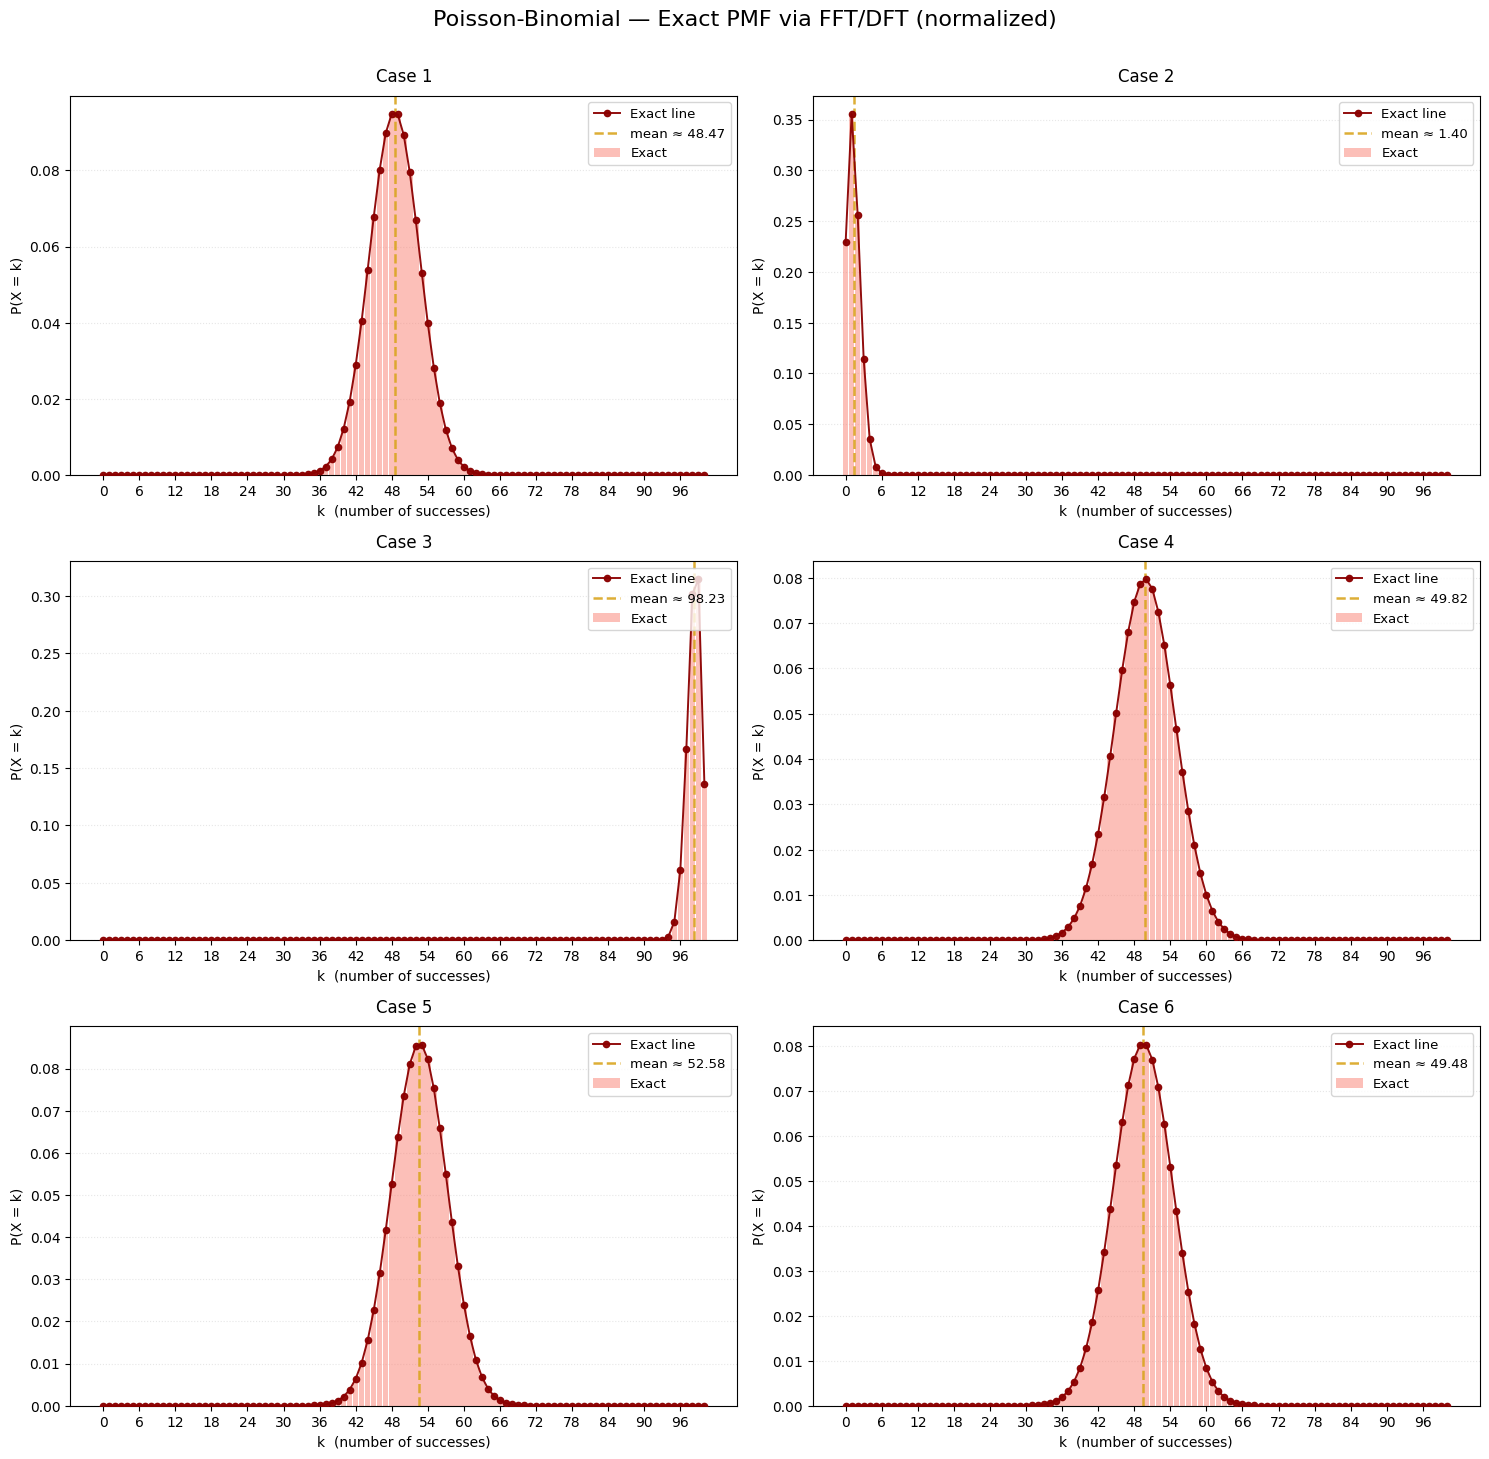

In [19]:
import torch
import math
import matplotlib.pyplot as plt
import numpy as np

# ── Paste the corrected PoissonBinomialExact class here ──
# (with the pmf() above)

def plot_pmf(pmf, title, ax=None, color='steelblue', is_exact=False):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 5.5))

    k = np.arange(len(pmf))
    p = pmf.numpy() if isinstance(pmf, torch.Tensor) else np.asarray(pmf)

    if is_exact:
        bar_color = 'salmon'
        line_color = 'darkred'
        label = 'Exact'
    else:
        bar_color = 'lightblue'
        line_color = 'royalblue'
        label = 'Approx'

    ax.bar(k, p, color=bar_color, alpha=0.5, width=0.92, label=label, zorder=2)
    ax.plot(k, p, 'o-', color=line_color, lw=1.4, markersize=4.5, alpha=0.95,
            label=f'{label} line', zorder=3)

    mean = np.sum(k * p)
    ax.axvline(mean, color='goldenrod', ls='--', lw=1.8, alpha=0.9,
               label=f'mean ≈ {mean:.2f}')

    ax.set_title(title, fontsize=12, pad=10)
    ax.set_xlabel('k  (number of successes)')
    ax.set_ylabel('P(X = k)')
    ax.grid(True, axis='y', alpha=0.3, ls=':')
    ax.legend(fontsize=9.5, loc='upper right')

    # Reasonable x-tick spacing
    step = max(1, len(k) // 15)
    ax.set_xticks(k[::step])

    return ax

# ── Plotting loop ───────────────────────────────────────

n_cases = len(test_cases)
fig, axes = plt.subplots(
    math.ceil(n_cases / 2), 2,
    figsize=(15, 4.8 * math.ceil(n_cases / 2)),
    squeeze=False
)
axes = axes.ravel()

for i, case in enumerate(test_cases):
    ax = axes[i]
    probs_t = torch.tensor(case[0], dtype=torch.float32)

    try:
        dist = PoissonBinomialExact(probs=probs_t)
        pmf_t = dist.pmf()
        plot_pmf(pmf_t, case_no[i], ax=ax, is_exact=True)
        print(f"✓ {case_no[i]}: sum(pmf) = {pmf_t.sum().item():.6f}")
    except Exception as e:
        ax.text(0.5, 0.5, f"Failed:\n{str(e)}", ha='center', va='center', color='red')
        print(f"✗ {case_no[i]}: {type(e).__name__} – {e}")

for ax in axes[n_cases:]:
    ax.set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.suptitle("Poisson-Binomial — Exact PMF via FFT/DFT (normalized)", fontsize=16, y=1.01)
plt.show()

C:\Users\matth\AppData\Local\Temp\ipykernel_368\3313288132.py:57: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  probs_t = torch.tensor(case[0], dtype=torch.float32)


✓ Case 1: sum(pmf) = 1.000000
✓ Case 2: sum(pmf) = 1.000000
✓ Case 3: sum(pmf) = 1.000000
✓ Case 4: sum(pmf) = 1.000000
✓ Case 5: sum(pmf) = 1.000000
✓ Case 6: sum(pmf) = 1.000000


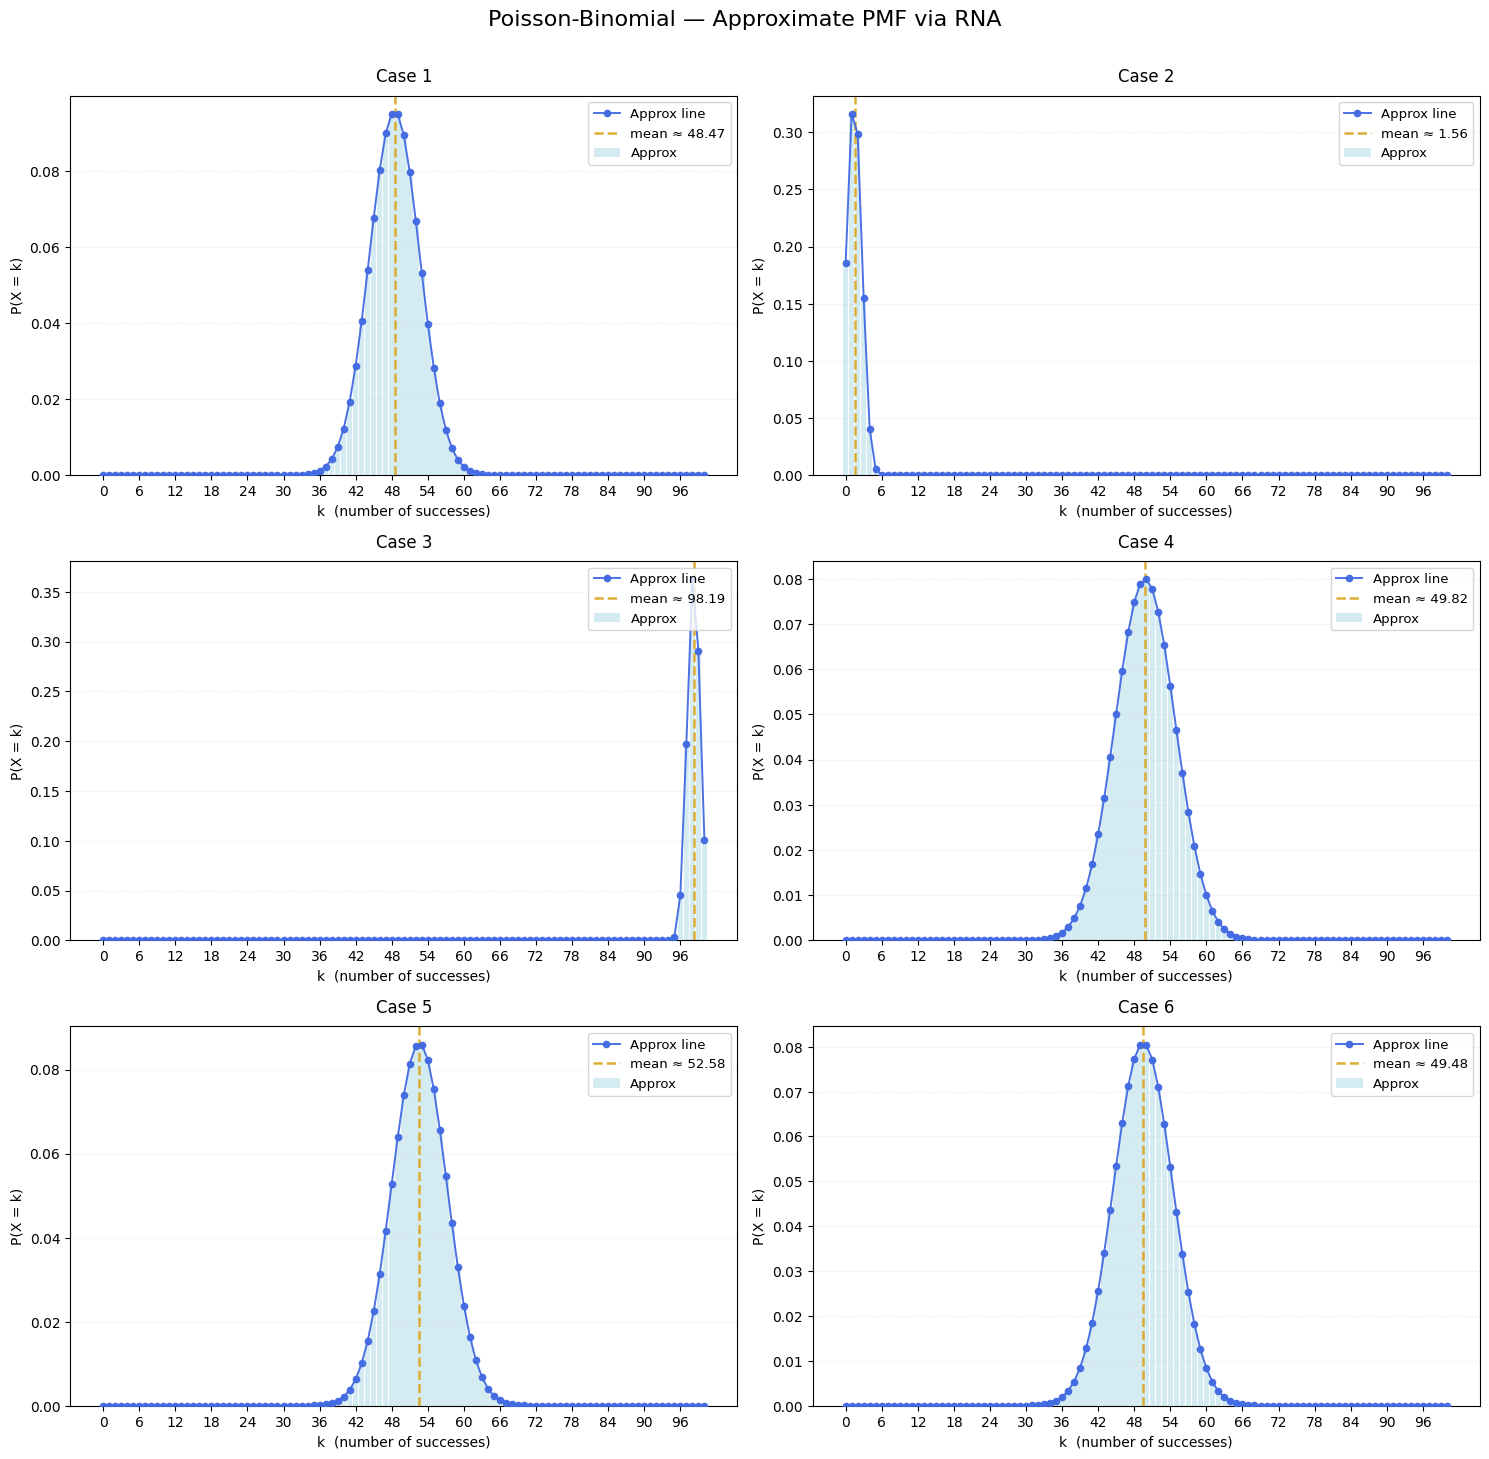

In [22]:
import torch
import math
import matplotlib.pyplot as plt
import numpy as np

# ── Paste the corrected PoissonBinomialApprox class here ──
# (with the pmf() above)

def plot_pmf(pmf, title, ax=None, color='steelblue', is_exact=False):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 5.5))

    k = np.arange(len(pmf))
    p = pmf.numpy() if isinstance(pmf, torch.Tensor) else np.asarray(pmf)

    if is_exact:
        bar_color = 'salmon'
        line_color = 'darkred'
        label = 'Exact'
    else:
        bar_color = 'lightblue'
        line_color = 'royalblue'
        label = 'Approx'

    ax.bar(k, p, color=bar_color, alpha=0.5, width=0.92, label=label, zorder=2)
    ax.plot(k, p, 'o-', color=line_color, lw=1.4, markersize=4.5, alpha=0.95,
            label=f'{label} line', zorder=3)

    mean = np.sum(k * p)
    ax.axvline(mean, color='goldenrod', ls='--', lw=1.8, alpha=0.9,
               label=f'mean ≈ {mean:.2f}')

    ax.set_title(title, fontsize=12, pad=10)
    ax.set_xlabel('k  (number of successes)')
    ax.set_ylabel('P(X = k)')
    ax.grid(True, axis='y', alpha=0.3, ls=':')
    ax.legend(fontsize=9.5, loc='upper right')

    # Reasonable x-tick spacing
    step = max(1, len(k) // 15)
    ax.set_xticks(k[::step])

    return ax

# ── Plotting loop ───────────────────────────────────────

n_cases = len(test_cases)
fig, axes = plt.subplots(
    math.ceil(n_cases / 2), 2,
    figsize=(15, 4.8 * math.ceil(n_cases / 2)),
    squeeze=False
)
axes = axes.ravel()

for i, case in enumerate(test_cases):
    ax = axes[i]
    probs_t = torch.tensor(case[0], dtype=torch.float32)

    try:
        dist = PoissonBinomialApprox(probs=probs_t)
        pmf_t = dist.pmf()           # corrected version returns normalized tensor
        plot_pmf(pmf_t, case_no[i], ax=ax, is_exact=False)
        print(f"✓ {case_no[i]}: sum(pmf) = {pmf_t.sum().item():.6f}")
    except Exception as e:
        ax.text(0.5, 0.5, f"Failed:\n{str(e)}", ha='center', va='center', color='red')
        print(f"✗ {case_no[i]}: {type(e).__name__} – {e}")

for ax in axes[n_cases:]:
    ax.set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.suptitle("Poisson-Binomial — Approximate PMF via RNA", fontsize=16, y=1.01)
plt.show()

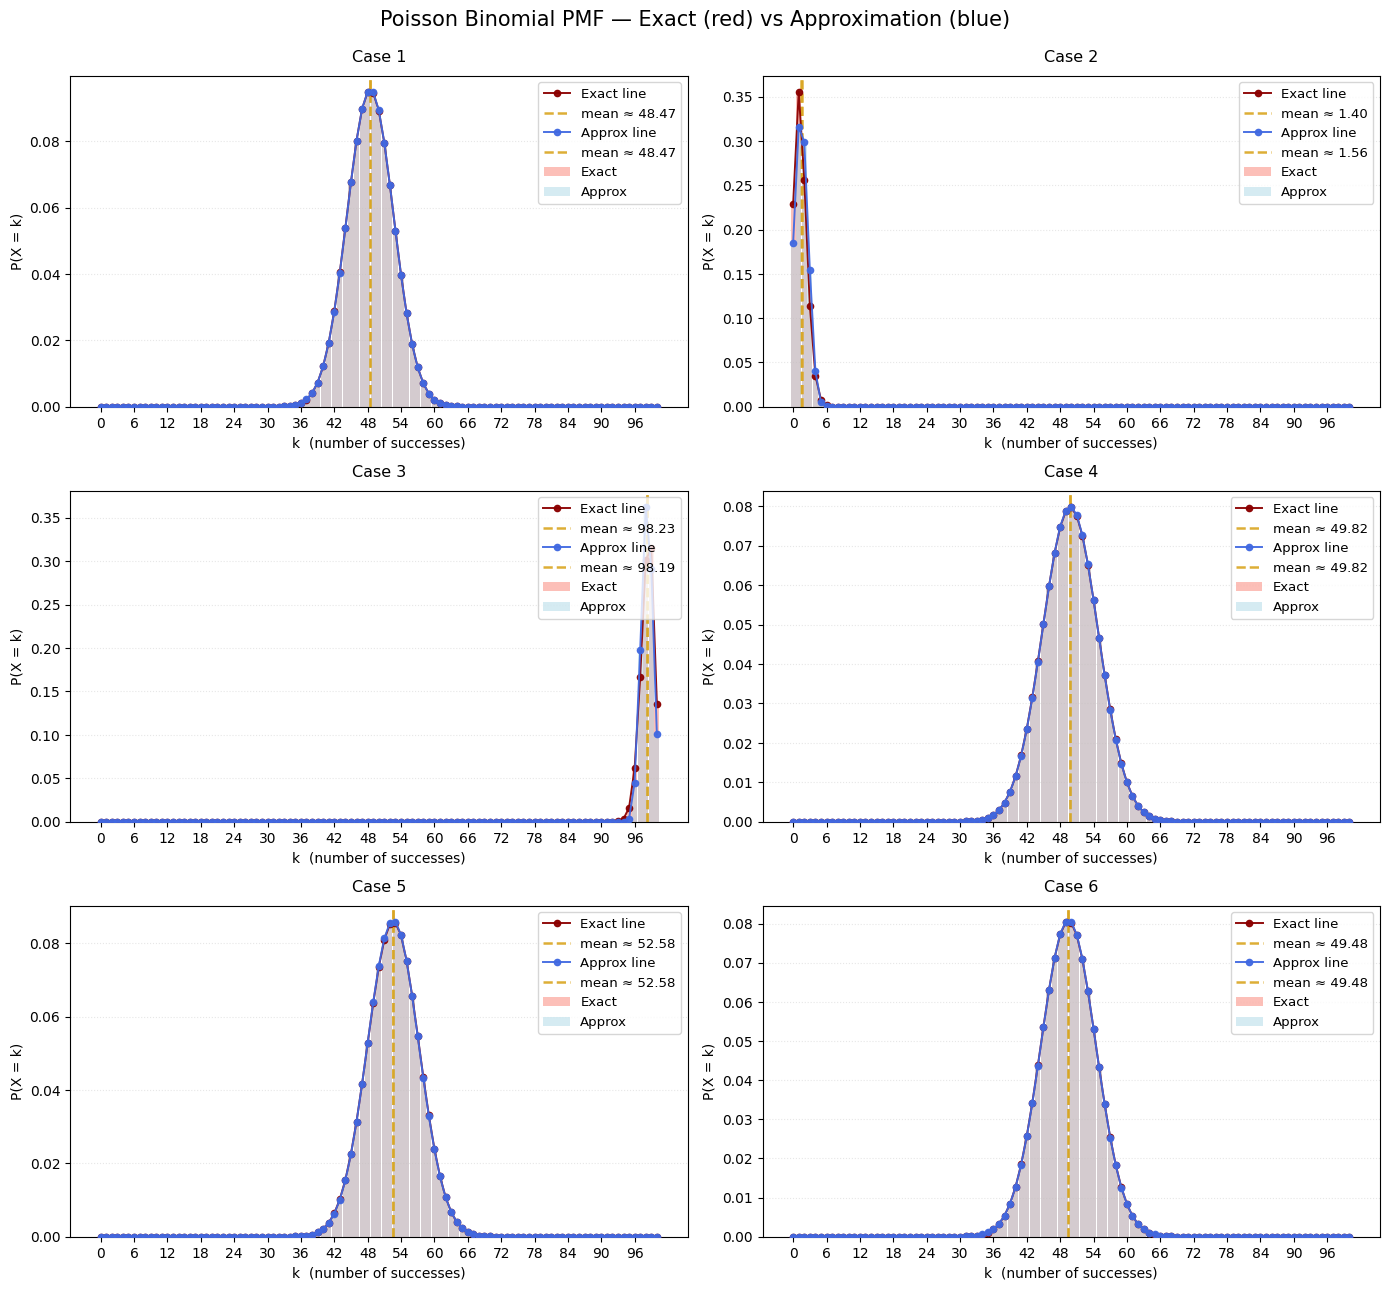

In [26]:
# ────────────────────────────────────────────────
#          Plot exact (red) vs approx (blue)
# ────────────────────────────────────────────────

n_cases = len(test_cases)
ncols = 2
nrows = math.ceil(n_cases / ncols)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(14, 4.2 * nrows),
    squeeze=False
)
axes = axes.flat

for i, case in enumerate(test_cases):
    ax = axes[i]

    # Exact → red
    dist_exact = PoissonBinomialExact(case[0])
    pmf_exact = dist_exact.pmf()
    plot_pmf(pmf_exact, title=case_no[i], ax=ax, is_exact=True)

    # Approximation → blue (overlaid)
    dist_approx = PoissonBinomialApprox(case[0])
    pmf_approx = dist_approx.pmf()
    plot_pmf(pmf_approx, title=case_no[i], ax=ax, is_exact=False)

    ax.set_title(f"{case_no[i]}", fontsize=11.5, pad=10)

# Hide empty subplots
for ax in axes[i+1:]:
    ax.set_visible(False)

plt.tight_layout()
plt.suptitle("Poisson Binomial PMF — Exact (red) vs Approximation (blue)", 
             fontsize=15, y=1.02)
plt.show()

## CDF

✓ Case 1: CDF(0) = 0.0000, CDF(end) = 1.0000
✓ Case 2: CDF(0) = 0.2289, CDF(end) = 1.0000
✓ Case 3: CDF(0) = 0.0000, CDF(end) = 1.0000
✓ Case 4: CDF(0) = 0.0000, CDF(end) = 1.0000
✓ Case 5: CDF(0) = 0.0000, CDF(end) = 1.0000
✓ Case 6: CDF(0) = 0.0000, CDF(end) = 1.0000


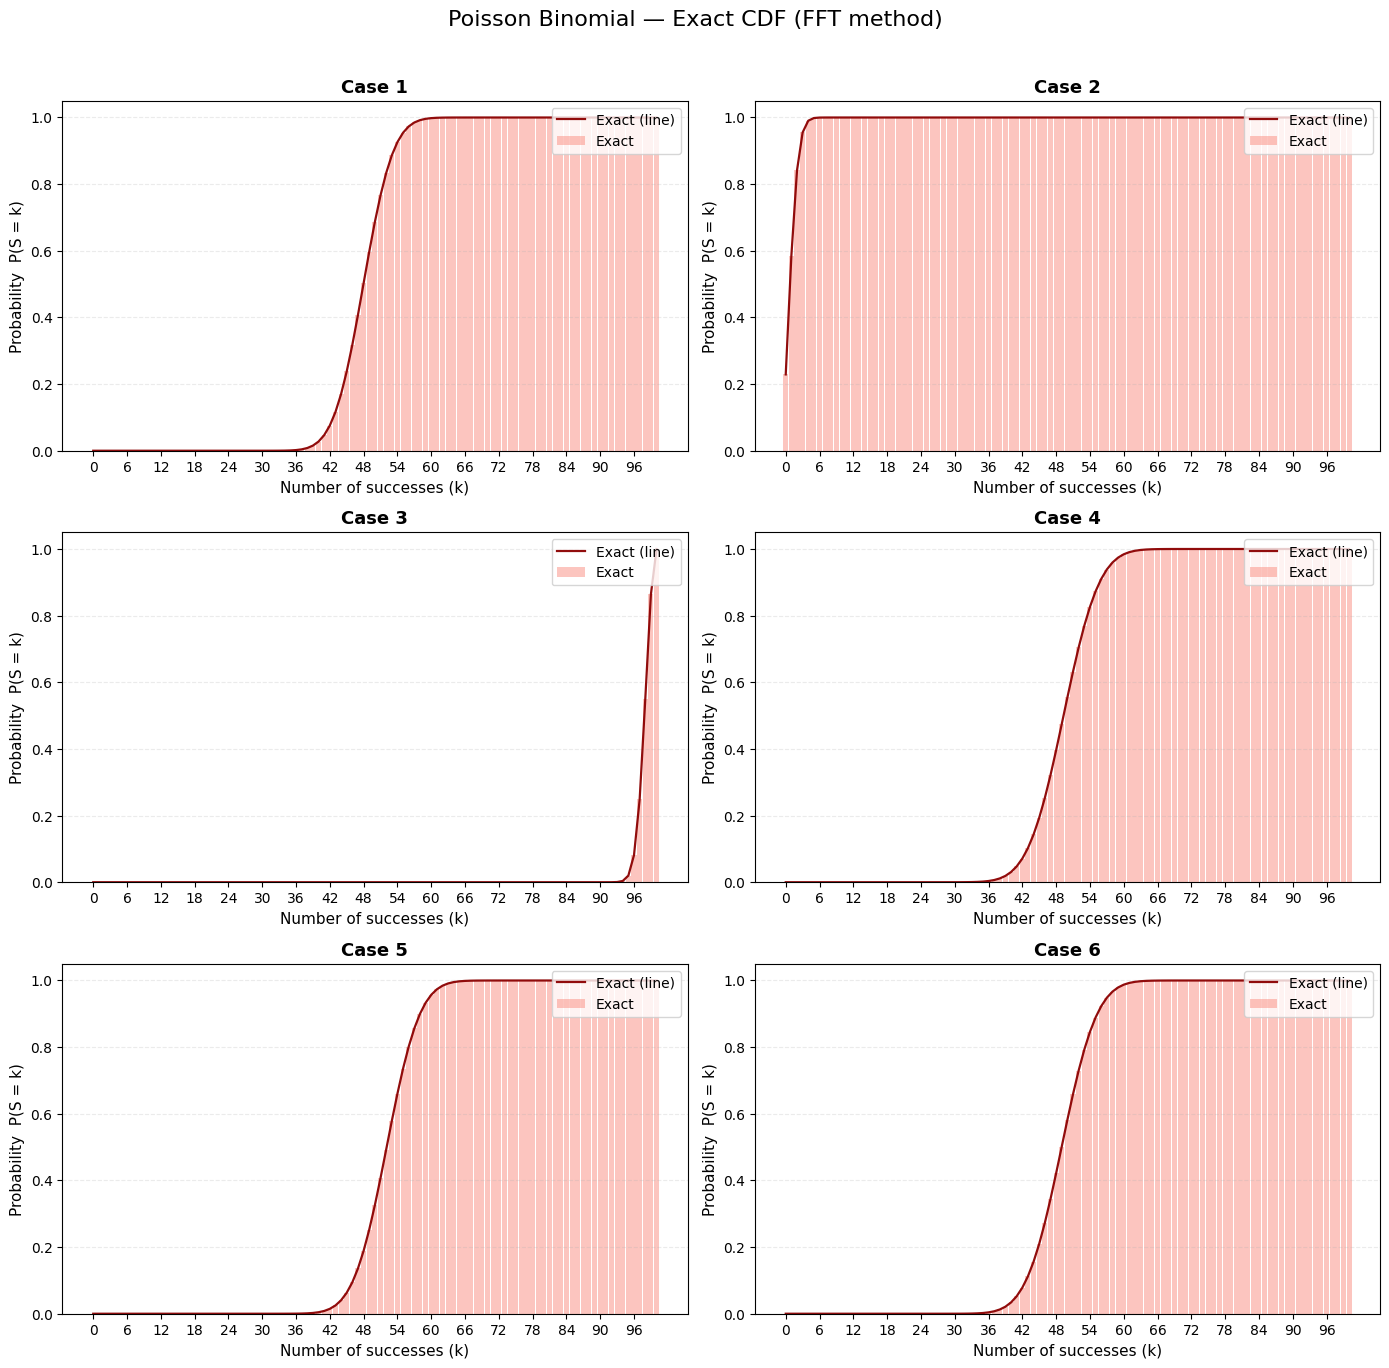

In [20]:
def plot_cdf(cdf, title, ax=None, color='steelblue', is_exact=False):
    """
    Plot CDF as line + markers.
    - is_exact=True  → uses red (exact distribution)
    - is_exact=False → uses blue (approximation)
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 5))

    k = np.arange(len(cdf))
    p = cdf.numpy() if hasattr(cdf, 'numpy') else np.asarray(cdf)

    # Choose style based on exact vs approx
    if is_exact:
        bar_color = 'salmon'
        line_color = 'darkred'
        label = 'Exact'
    else:
        bar_color = 'lightblue'
        line_color = 'royalblue'
        label = 'Approximation'

    # Bars (faint) + line + markers (prominent)
    ax.bar(k, p, color=bar_color, alpha=0.45, edgecolor='none', width=0.9, label=label)
    ax.plot(k, p, '-', color=line_color, lw=1.6, markersize=6, alpha=0.95,
            label=f'{label} (line)')

    # Styling
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Number of successes (k)', fontsize=11)
    ax.set_ylabel('Probability  P(S = k)', fontsize=11)
    ax.grid(True, axis='y', alpha=0.25, linestyle='--')

    # Mean vertical line
    #mean = np.sum(k * p)
    #ax.axvline(mean, color='goldenrod', ls='--', lw=1.9, alpha=0.85,
    #           label=f'mean = {mean:.3f}')

    ax.legend(fontsize=10, loc='upper right')

    # Cleaner x-ticks when many points
    if len(k) > 20:
        ax.set_xticks(k[::max(1, len(k)//15)])

    return ax

n_cases = len(test_cases)
ncols = 2
nrows = math.ceil(n_cases / ncols)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(14, 4.5 * nrows),
    squeeze=False
)
axes = axes.flat

for i, case in enumerate(test_cases):
    ax = axes[i]

    try:
        probs_t = torch.as_tensor(case[0], dtype=torch.float32)
        dist = PoissonBinomialExact(probs=probs_t)
        
        # This is the key: get the full CDF vector
        cdf_full = dist.cdf()           # returns tensor shape [n+1]
        
        plot_cdf(
            cdf_full,
            title=case_no[i],
            ax=ax,
            is_exact=True
        )
        
        print(f"✓ {case_no[i]}: CDF(0) = {cdf_full[0]:.4f}, CDF(end) = {cdf_full[-1]:.4f}")
        
    except Exception as e:
        ax.text(0.5, 0.5, f"Error:\n{str(e)}", ha='center', va='center', color='red', fontsize=11)
        print(f"✗ {case_no[i]}: {type(e).__name__} – {e}")

# Hide unused subplots
for ax in axes[n_cases:]:
    ax.set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.suptitle("Poisson Binomial — Exact CDF (FFT method)", fontsize=16, y=1.01)
plt.show()

✓ Case 1: CDF(0) = 0.0000, CDF(end) = 1.0000
✓ Case 2: CDF(0) = 0.1852, CDF(end) = 1.0000
✓ Case 3: CDF(0) = 0.0000, CDF(end) = 1.0000
✓ Case 4: CDF(0) = 0.0000, CDF(end) = 1.0000
✓ Case 5: CDF(0) = 0.0000, CDF(end) = 1.0000
✓ Case 6: CDF(0) = 0.0000, CDF(end) = 1.0000


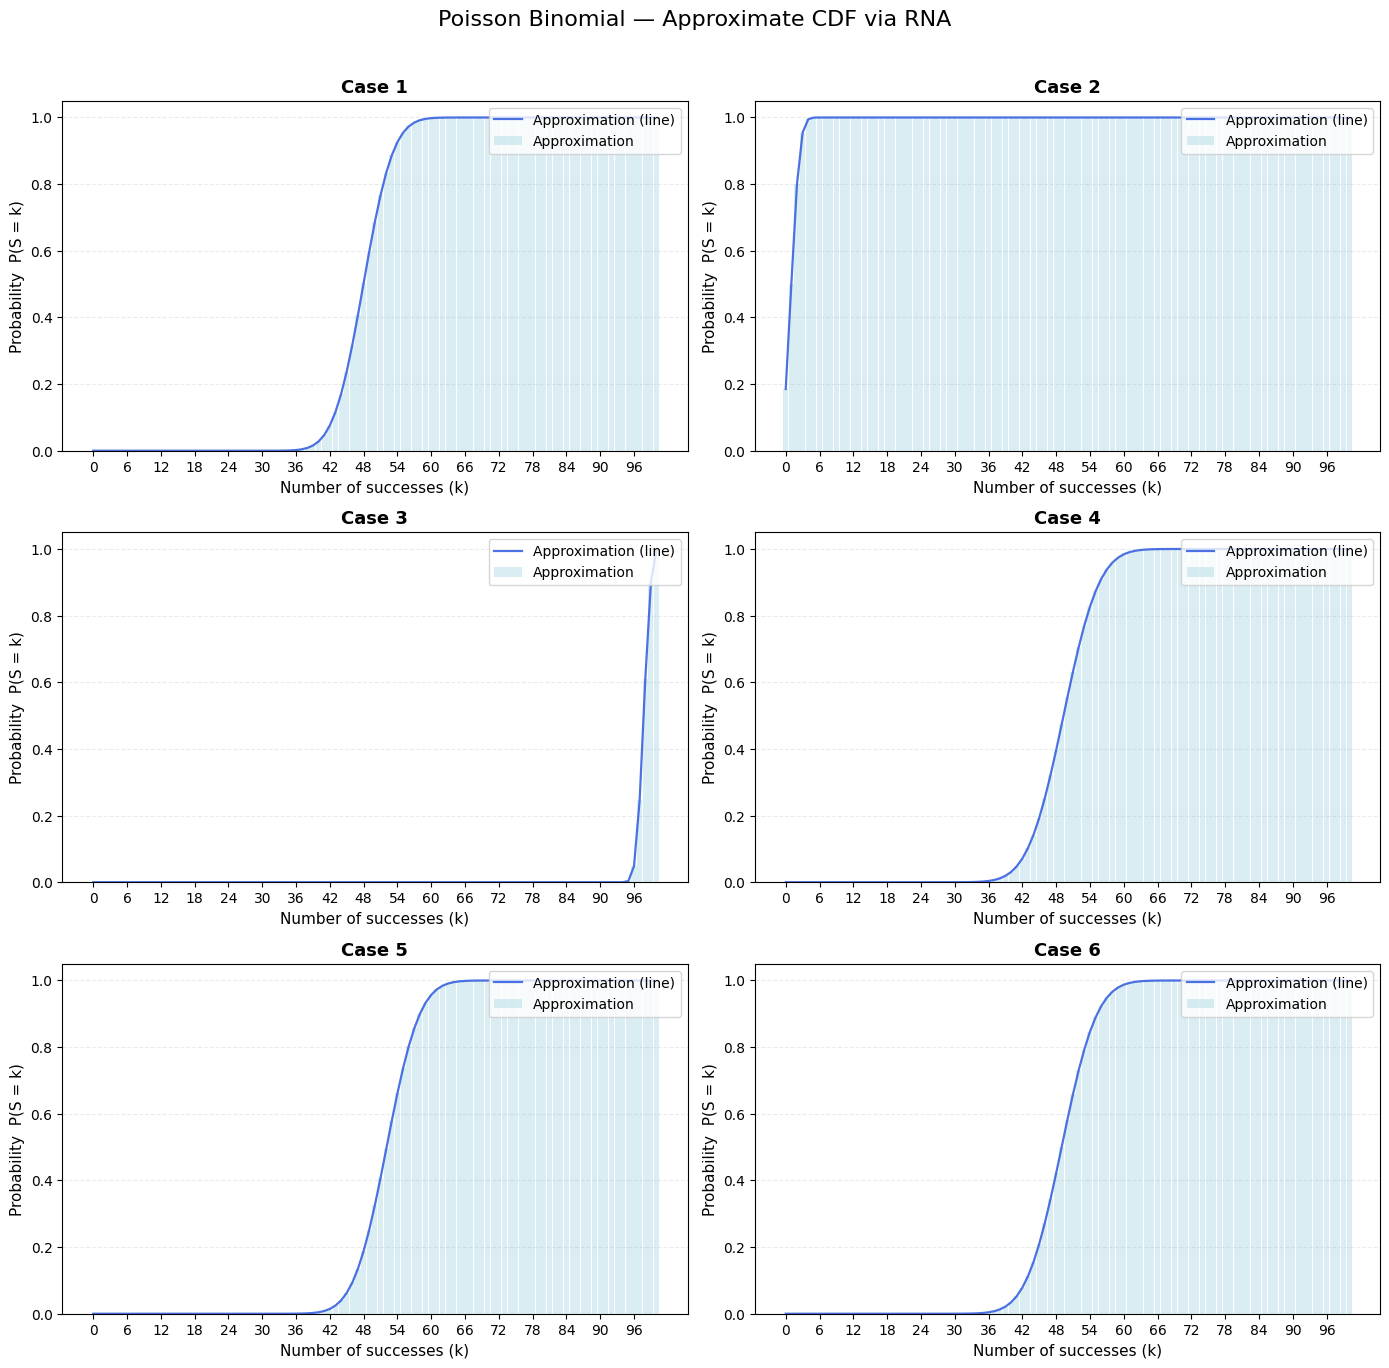

In [23]:
def plot_cdf(cdf, title, ax=None, color='steelblue', is_exact=False):
    """
    Plot CDF as line + markers.
    - is_exact=True  → uses red (exact distribution)
    - is_exact=False → uses blue (approximation)
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 5))

    k = np.arange(len(cdf))
    p = cdf.numpy() if hasattr(cdf, 'numpy') else np.asarray(cdf)

    # Choose style based on exact vs approx
    if is_exact:
        bar_color = 'salmon'
        line_color = 'darkred'
        label = 'Exact'
    else:
        bar_color = 'lightblue'
        line_color = 'royalblue'
        label = 'Approximation'

    # Bars (faint) + line + markers (prominent)
    ax.bar(k, p, color=bar_color, alpha=0.45, edgecolor='none', width=0.9, label=label)
    ax.plot(k, p, '-', color=line_color, lw=1.6, markersize=6, alpha=0.95,
            label=f'{label} (line)')

    # Styling
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Number of successes (k)', fontsize=11)
    ax.set_ylabel('Probability  P(S = k)', fontsize=11)
    ax.grid(True, axis='y', alpha=0.25, linestyle='--')

    # Mean vertical line
    #mean = np.sum(k * p)
    #ax.axvline(mean, color='goldenrod', ls='--', lw=1.9, alpha=0.85,
    #           label=f'mean = {mean:.3f}')

    ax.legend(fontsize=10, loc='upper right')

    # Cleaner x-ticks when many points
    if len(k) > 20:
        ax.set_xticks(k[::max(1, len(k)//15)])

    return ax

n_cases = len(test_cases)
ncols = 2
nrows = math.ceil(n_cases / ncols)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(14, 4.5 * nrows),
    squeeze=False
)
axes = axes.flat

for i, case in enumerate(test_cases):
    ax = axes[i]

    try:
        probs_t = torch.as_tensor(case[0], dtype=torch.float32)
        dist = PoissonBinomialApprox(probs=probs_t)
        
        # This is the key: get the full CDF vector
        cdf_full = dist.cdf()           # returns tensor shape [n+1]
        
        plot_cdf(
            cdf_full,
            title=case_no[i],
            ax=ax,
            is_exact=False
        )
        
        print(f"✓ {case_no[i]}: CDF(0) = {cdf_full[0]:.4f}, CDF(end) = {cdf_full[-1]:.4f}")
        
    except Exception as e:
        ax.text(0.5, 0.5, f"Error:\n{str(e)}", ha='center', va='center', color='red', fontsize=11)
        print(f"✗ {case_no[i]}: {type(e).__name__} – {e}")

# Hide unused subplots
for ax in axes[n_cases:]:
    ax.set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.suptitle("Poisson Binomial — Approximate CDF via RNA", fontsize=16, y=1.01)
plt.show()

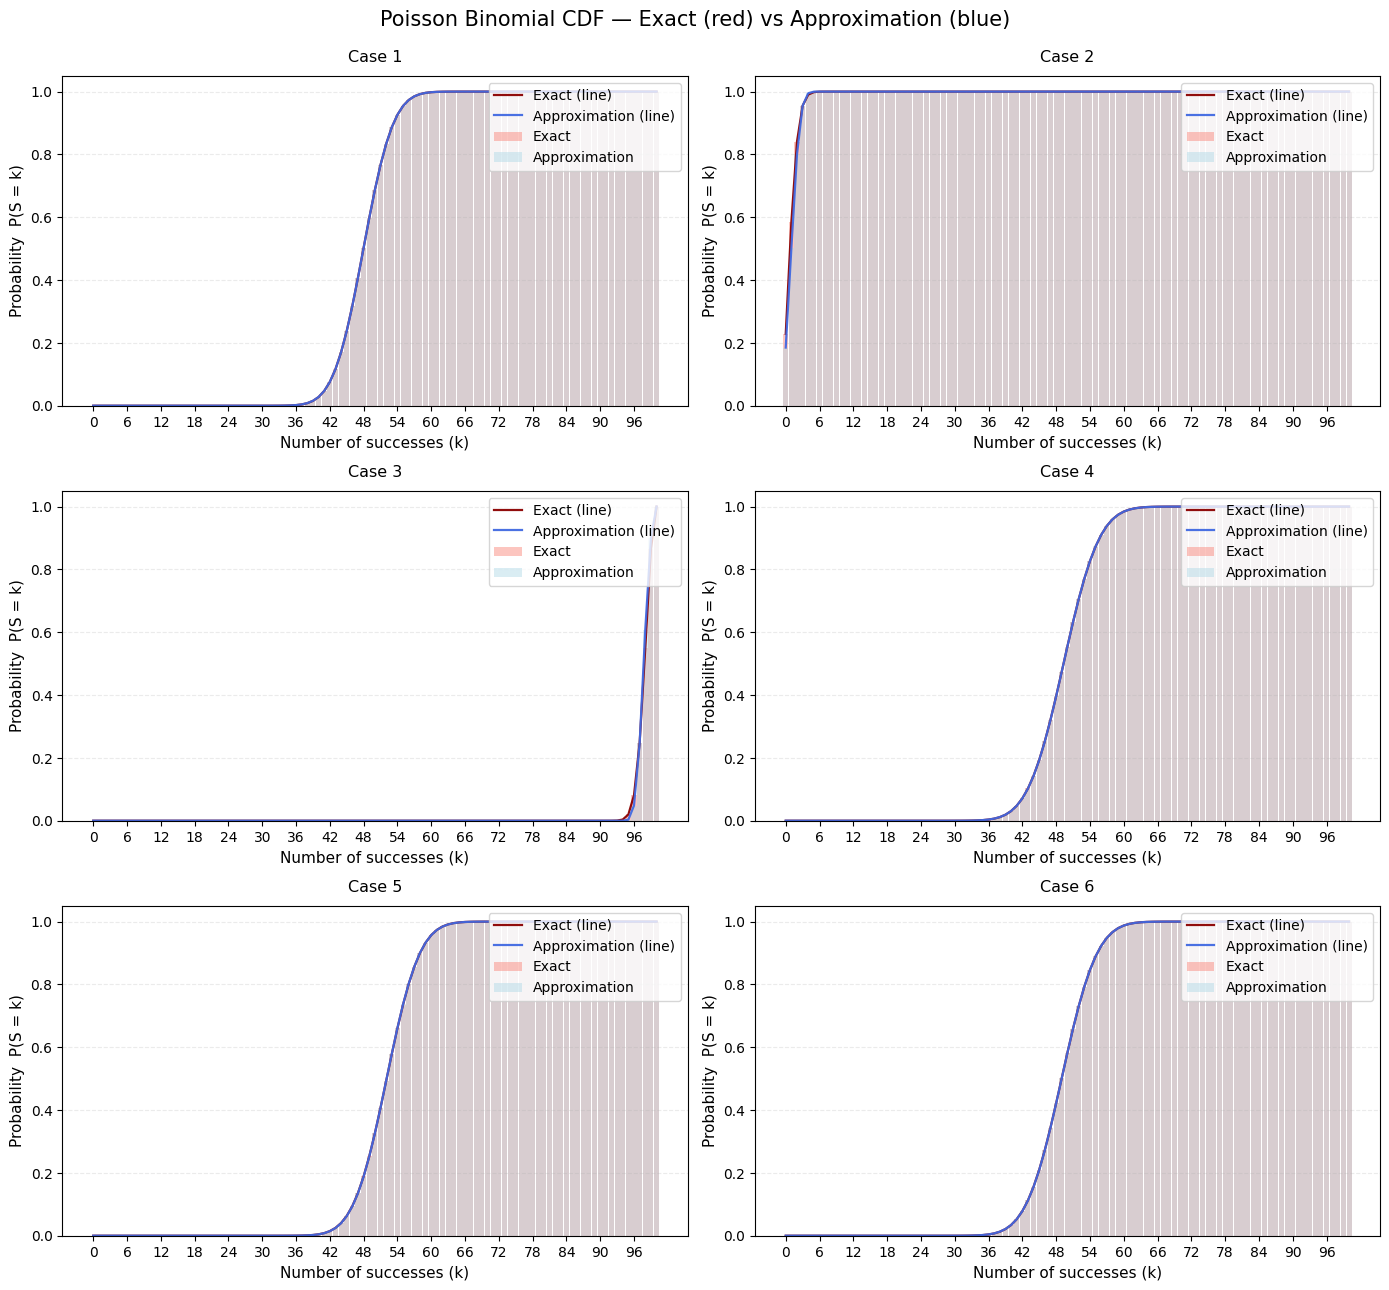

In [27]:
# ────────────────────────────────────────────────
#          Plot exact (red) vs approx (blue)
# ────────────────────────────────────────────────

n_cases = len(test_cases)
ncols = 2
nrows = math.ceil(n_cases / ncols)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(14, 4.2 * nrows),
    squeeze=False
)
axes = axes.flat

for i, case in enumerate(test_cases):
    ax = axes[i]

    # Exact → red
    dist_exact = PoissonBinomialExact(case[0])
    cdf_exact = dist_exact.cdf()
    plot_cdf(cdf_exact, title=case_no[i], ax=ax, is_exact=True)

    # Approximation → blue (overlaid)
    dist_approx = PoissonBinomialApprox(case[0])
    cdf_approx = dist_approx.cdf()
    plot_cdf(cdf_approx, title=case_no[i], ax=ax, is_exact=False)

    ax.set_title(f"{case_no[i]}", fontsize=11.5, pad=10)


# Hide empty subplots
for ax in axes[i+1:]:
    ax.set_visible(False)

plt.tight_layout()
plt.suptitle("Poisson Binomial CDF — Exact (red) vs Approximation (blue)", 
             fontsize=15, y=1.02)
plt.show()

## ICDF

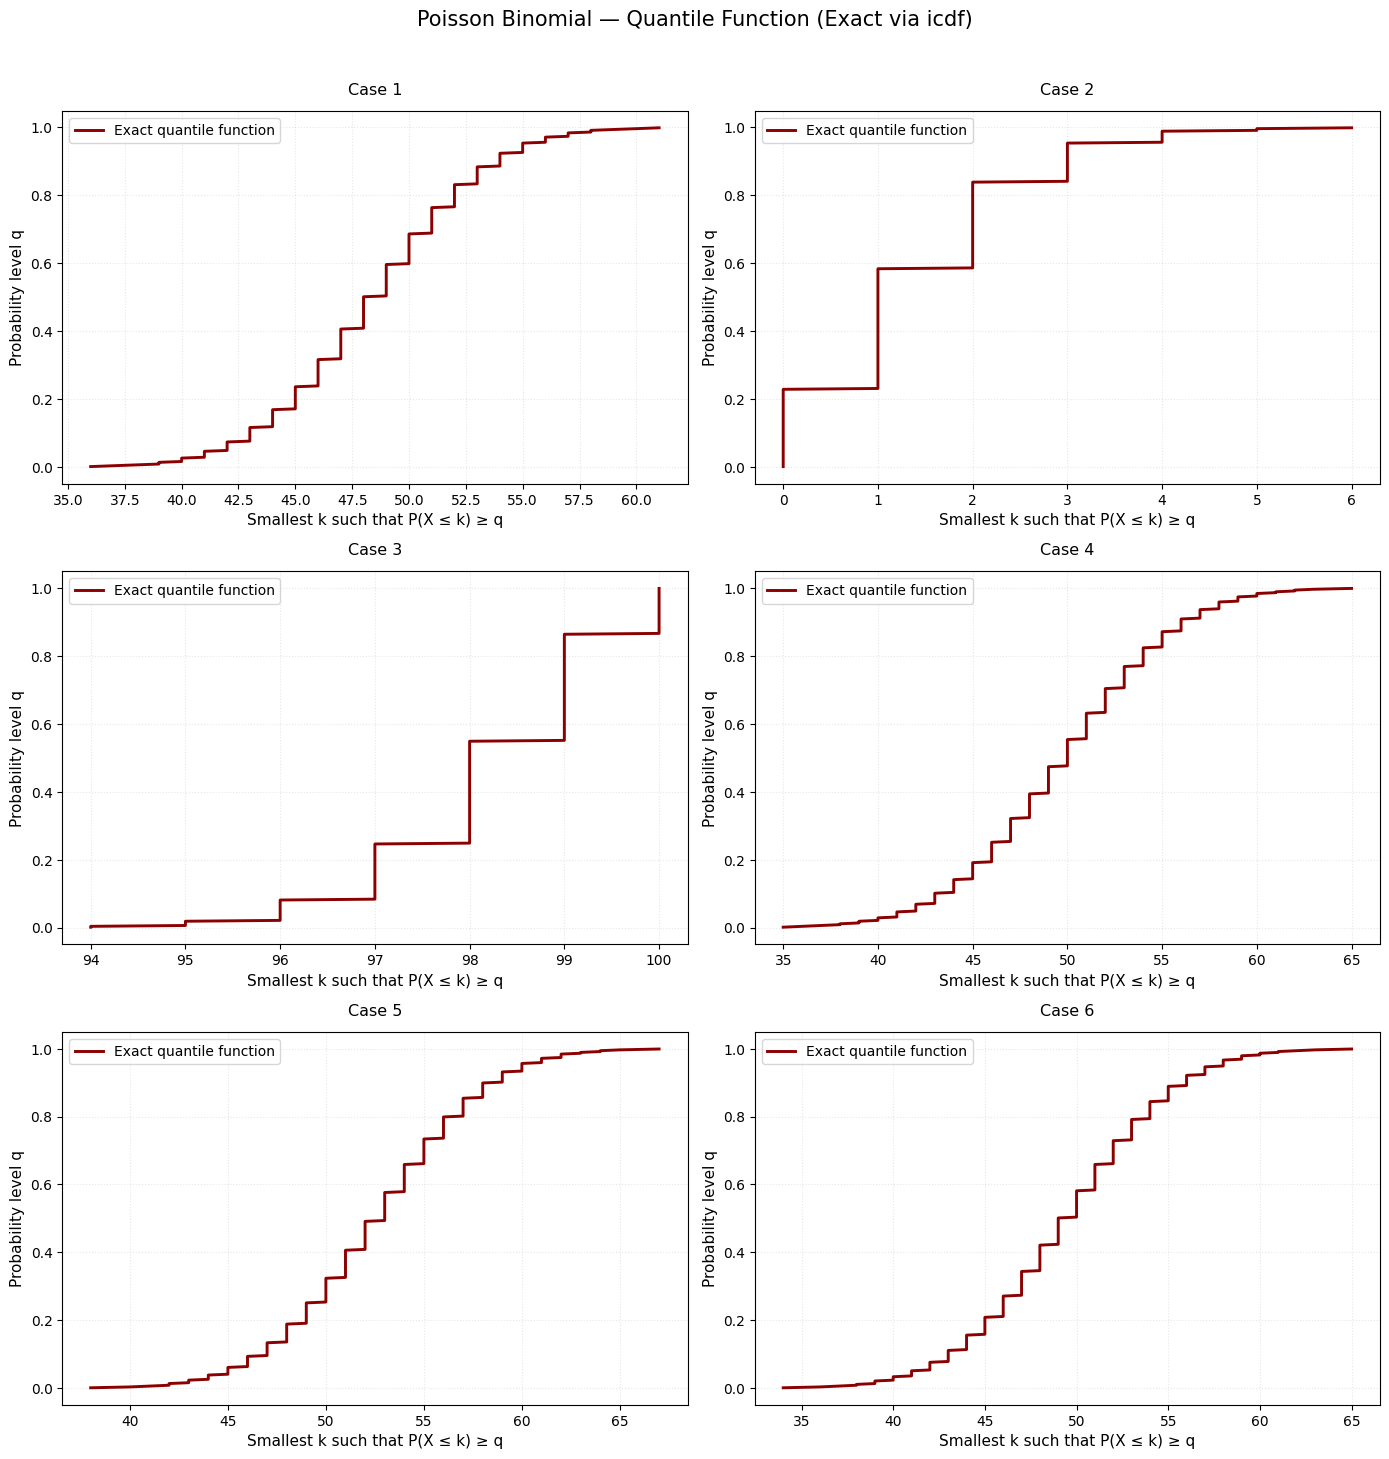

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import torch

def plot_quantile_function(probs, title, ax=None, is_exact=True, n_points=300):
    """
    Plot the quantile function (inverse CDF) of a Poisson-binomial distribution.
    
    Parameters:
    - probs: list, np.array or torch.Tensor of success probabilities
    - title: str
    - ax: matplotlib axis (optional)
    - is_exact: bool (currently only exact is implemented)
    - n_points: number of evaluation points in [0,1]
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 5.5))

    # Evaluation points — avoid exact 0 and 1 to prevent edge artifacts
    q = np.linspace(0.001, 0.999, n_points)
    q_tensor = torch.tensor(q, dtype=torch.float32)

    # Convert probs once
    probs_t = torch.as_tensor(probs, dtype=torch.float32)

    try:
        dist = PoissonBinomialExact(probs=probs_t)
        
        # Core: evaluate icdf at many points (vectorized!)
        k_values = dist.icdf(q_tensor)           # shape [n_points]
        
        # For discrete distributions, icdf(q) is right-continuous
        # We usually plot as step function or connected line
        ax.plot(k_values.numpy(), q, '-', color='darkred', lw=2.1,
                label='Exact quantile function')
        
        # Optional: add faint step appearance
        # ax.step(k_values.numpy(), q, where='post', color='darkred', lw=1.8,
        #         label='Exact (step)', alpha=0.7)

        ax.set_title(f"{title}\nQuantile Function (Exact)", fontsize=12, pad=10)
        
    except Exception as e:
        ax.text(0.5, 0.5, f"Error:\n{str(e)}", ha='center', va='center',
                color='red', fontsize=11)
        print(f"Failed {title}: {e}")
        return ax

    ax.set_xlabel('Smallest k such that P(X ≤ k) ≥ q', fontsize=11)
    ax.set_ylabel('Probability level q', fontsize=11)
    ax.grid(True, alpha=0.3, ls=':')
    ax.legend(fontsize=10, loc='upper left')

    # Because k is integer-valued, force integer ticks on x
    #max_k = int(k_values.max().item()) + 1
    #ax.set_xticks(np.arange(0, max_k + 1, max(1, max_k // 12)))
    ax.locator_params(axis='x', nbins=12)
    return ax


# ────────────────────────────────────────────────
#          Plotting loop — one panel per test case
# ────────────────────────────────────────────────

n_cases = len(test_cases)
ncols = 2
nrows = math.ceil(n_cases / ncols)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(14, 4.8 * nrows),
    squeeze=False
)
axes = axes.flat

for i, case in enumerate(test_cases):
    ax = axes[i]
    
    plot_quantile_function(
        probs     = case[0],
        title     = case_no[i],
        ax        = ax,
        is_exact  = True,
        n_points  = 400   # smoother curve, especially useful for n≈100
    )
    
    ax.set_title(case_no[i], fontsize=11.5, pad=12)

# Hide empty subplots
for ax in axes[n_cases:]:
    ax.set_visible(False)

plt.tight_layout(rect=[0, 0.0, 1, 0.97])
plt.suptitle("Poisson Binomial — Quantile Function (Exact via icdf)", 
             fontsize=15, y=1.01)
plt.show()

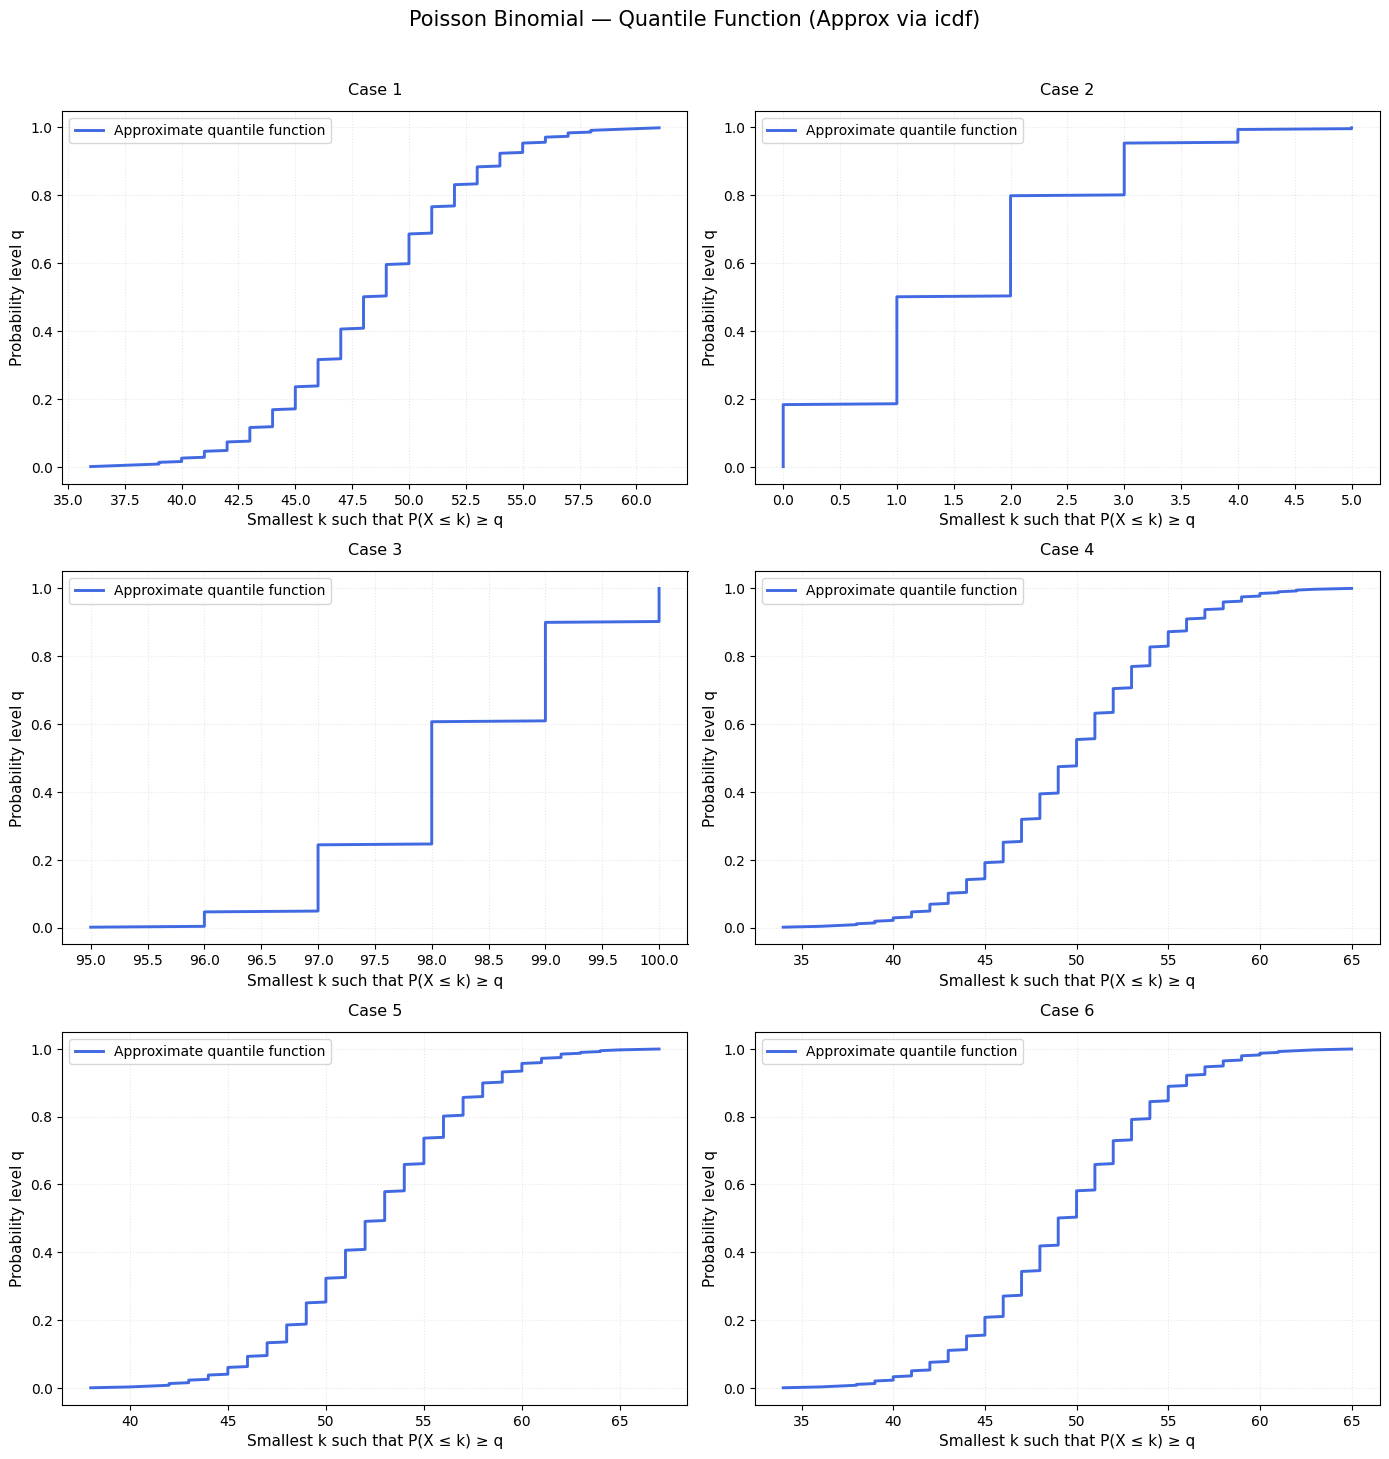

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import torch

def plot_quantile_function(probs, title, ax=None, is_exact=True, n_points=300):
    """
    Plot the quantile function (inverse CDF) of a Poisson-binomial distribution.
    
    Parameters:
    - probs: list, np.array or torch.Tensor of success probabilities
    - title: str
    - ax: matplotlib axis (optional)
    - is_exact: bool (currently only exact is implemented)
    - n_points: number of evaluation points in [0,1]
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 5.5))

    # Evaluation points — avoid exact 0 and 1 to prevent edge artifacts
    q = np.linspace(0.001, 0.999, n_points)
    q_tensor = torch.tensor(q, dtype=torch.float32)

    # Convert probs once
    probs_t = torch.as_tensor(probs, dtype=torch.float32)

    try:
        dist = PoissonBinomialApprox(probs=probs_t)
        
        # Core: evaluate icdf at many points (vectorized!)
        k_values = dist.icdf(q_tensor)           # shape [n_points]
       
       
        # For discrete distributions, icdf(q) is right-continuous
        # We usually plot as step function or connected line
        ax.plot(k_values.numpy(), q, '-', color='royalblue', lw=2.1,
                label='Approximate quantile function')
        
        # Optional: add faint step appearance
        # ax.step(k_values.numpy(), q, where='post', color='darkred', lw=1.8,
        #         label='Exact (step)', alpha=0.7)

        ax.set_title(f"{title}\nQuantile Function (Approximate)", fontsize=12, pad=10)
        
    except Exception as e:
        ax.text(0.5, 0.5, f"Error:\n{str(e)}", ha='center', va='center',
                color='red', fontsize=11)
        print(f"Failed {title}: {e}")
        return ax

    ax.set_xlabel('Smallest k such that P(X ≤ k) ≥ q', fontsize=11)
    ax.set_ylabel('Probability level q', fontsize=11)
    ax.grid(True, alpha=0.3, ls=':')
    ax.legend(fontsize=10, loc='upper left')

    # Because k is integer-valued, force integer ticks on x
    #max_k = int(k_values.max().item()) + 1
    #ax.set_xticks(np.arange(0, max_k + 1, max(1, max_k // 12)))
    ax.locator_params(axis='x', nbins=12)
    return ax


# ────────────────────────────────────────────────
#          Plotting loop — one panel per test case
# ────────────────────────────────────────────────

n_cases = len(test_cases)
ncols = 2
nrows = math.ceil(n_cases / ncols)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(14, 4.8 * nrows),
    squeeze=False
)
axes = axes.flat

for i, case in enumerate(test_cases):
    ax = axes[i]
    
    plot_quantile_function(
        probs     = case[0],
        title     = case_no[i],
        ax        = ax,
        is_exact  = False,
        n_points  = 400   # smoother curve, especially useful for n≈100
    )
    
    ax.set_title(case_no[i], fontsize=11.5, pad=12)

# Hide empty subplots
for ax in axes[n_cases:]:
    ax.set_visible(False)

plt.tight_layout(rect=[0, 0.0, 1, 0.97])
plt.suptitle("Poisson Binomial — Quantile Function (Approx via icdf)", 
             fontsize=15, y=1.01)
plt.show()

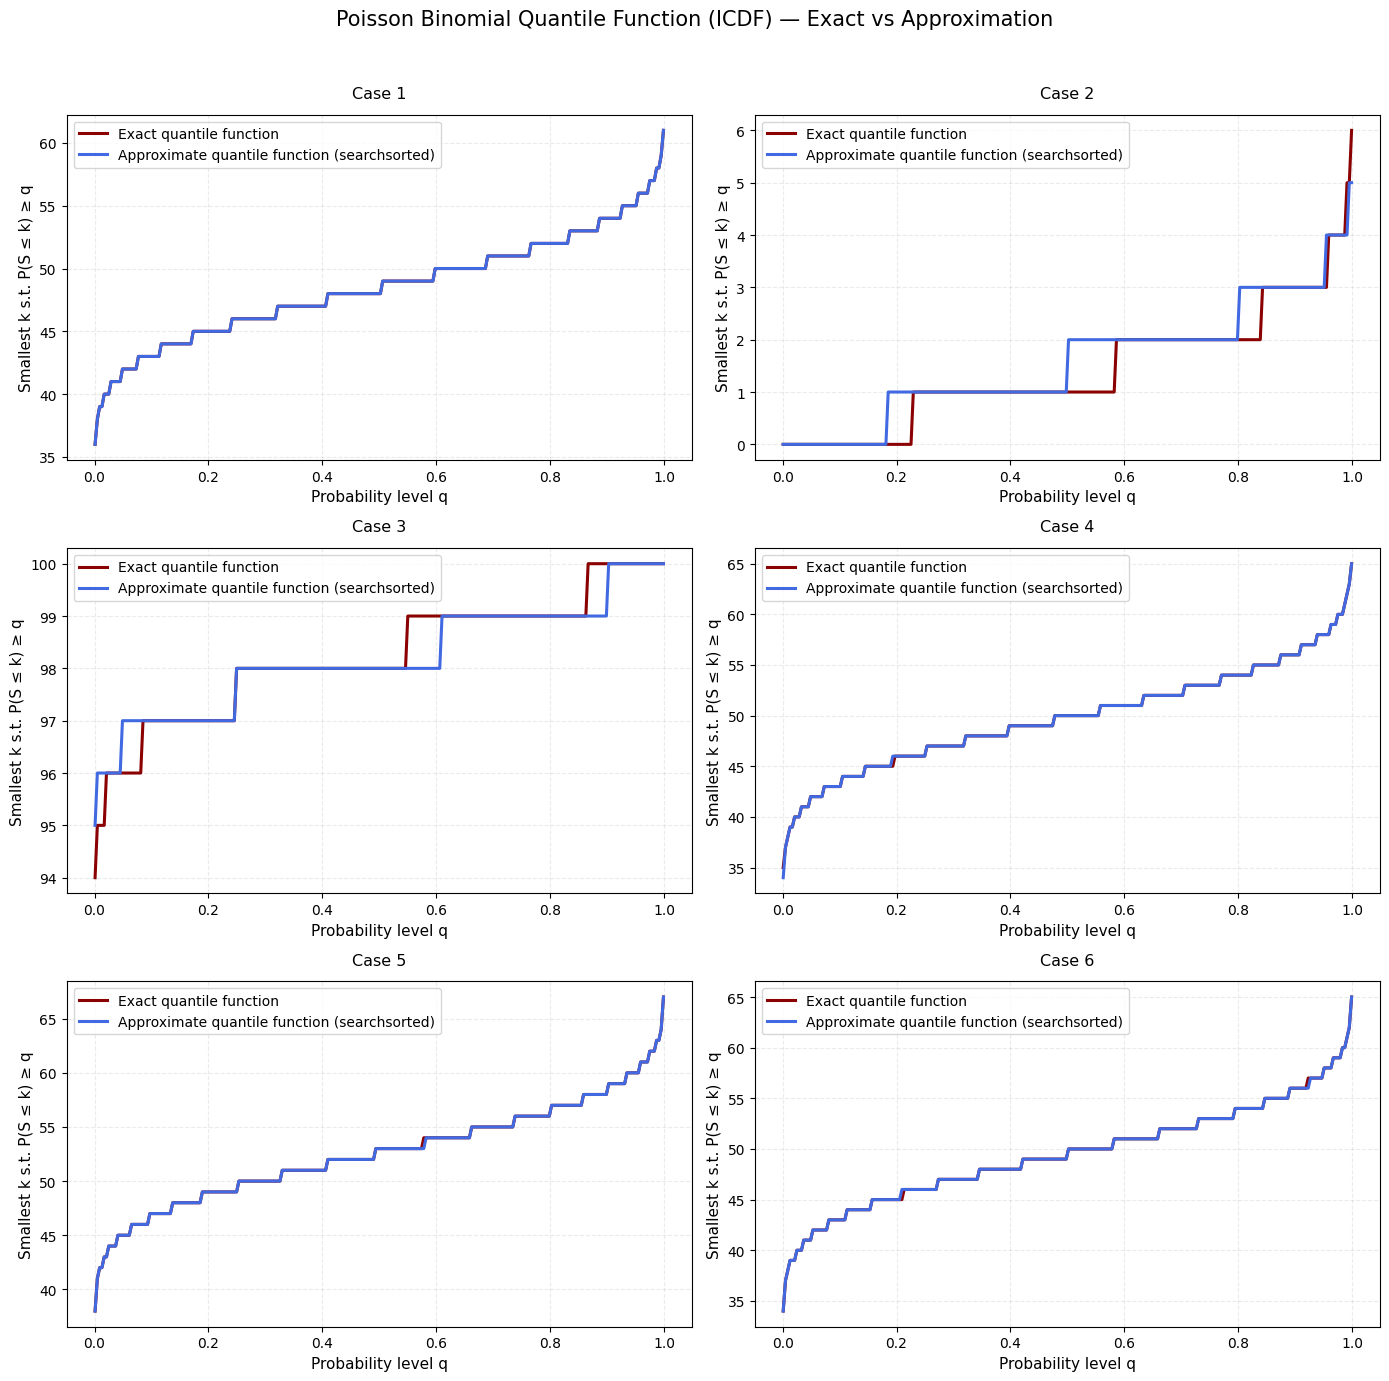

In [31]:
def plot_quantile_function(probs, title, ax=None, is_exact=True, n_points=250, method='searchsorted'):
    """
    Plot the quantile function (inverse CDF) by evaluating at many points.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 5.5))

    # Evaluation points in probability space
    q = np.linspace(0.001, 0.999, n_points)

    if is_exact:
        color = 'darkred'
        label = 'Exact quantile function'
        quantiles = []
        dist = PoissonBinomialExact(probs)
        for qi in q:
            k = dist.icdf(qi)
            quantiles.append(k.item() if torch.is_tensor(k) else k)

    else:
        color = 'royalblue'
        label = 'Approximate quantile function (searchsorted)'
        quantiles = []
        dist = PoissonBinomialApprox(probs)
        for qi in q:
            k = dist.icdf(qi, method=method)
            quantiles.append(k.item() if torch.is_tensor(k) else k)
        
    quantiles = np.array(quantiles)

    # Plot
    ax.plot(q, quantiles, '-', color=color, lw=2.2, label=label)
    #ax.plot(q, quantiles, 'o', color=color, ms=4, alpha=0.6, markeredgecolor='none')

    ax.set_title(f"{title}\n({label})", fontsize=12, pad=10)
    ax.set_xlabel('Probability level q', fontsize=11)
    ax.set_ylabel('Smallest k s.t. P(S ≤ k) ≥ q', fontsize=11)
    ax.grid(True, alpha=0.25, ls='--')
    ax.legend(fontsize=10, loc='upper left')

    # Optional: step-like appearance (more accurate for discrete)
    #ax.step(q, quantiles, where='post', color=color, lw=2.2, label=label)

    return ax

# ────────────────────────────────────────────────
#          Plot exact (red) vs approx (blue)
# ────────────────────────────────────────────────

n_cases = len(test_cases)
ncols = 2
nrows = math.ceil(n_cases / ncols)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(14, 4.5 * nrows),
    squeeze=False
)
axes = axes.flat

for i, case in enumerate(test_cases):
    ax = axes[i]

    # Exact → red
    plot_quantile_function(
        probs     = case[0],
        title     = case_no[i],
        ax        = ax,
        is_exact  = True
    )

    # Approximation → blue (overlaid)
    plot_quantile_function(
        probs     = case[0],
        title     = case_no[i],
        ax        = ax,
        is_exact  = False
    )
    
    ax.set_title(
        f"{case_no[i]}",
        fontsize=11.5,
        pad=12
    )

# Hide unused subplots
for ax in axes[i+1:]:
    ax.set_visible(False)

plt.suptitle("Poisson Binomial Quantile Function (ICDF) — Exact vs Approximation",
             fontsize=15, y=1.02)
plt.tight_layout()
plt.show()